# **توضیح نحوه نوشتن تکست ها**
**در تکست ها کد ها توضیح داده شده اند اما کد هایی که تکراری باشند دیگه توضیح نمیدهم.**

**یه سری خطوط به صورت مکرر در پروژه تکرار شده اند که حداقل یک بار نحوه کار آن ها توضیح داده شده است.**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display, HTML
import io
import base64
from scipy import stats
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve, fbeta_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

## تعریف تابع ها
در این بخش تابع هایی ساختم که جدول و متن ها را به وسط صفحه بیاورد که این کار را به کمک html انجام میدهد.

In [3]:
def print_center_txt(txt, size=15):
  font_size = f'{size}px' if isinstance(size, (int, float)) else str(size)

  display(
      HTML(f"""
    <div style="display: flex; justify-content: center; width: 100%; margin: 20px 0;">
        <div style="
            background: #f8fafc;
            border: 1.5px solid #cbd5e1;
            border-radius: 10px;
            padding: 14px 28px;
            box-shadow: 0 4px 10px rgba(0, 0, 0, 0.06);
            text-align: center;
            display: inline-block;
            max-width: 80%;
            direction: auto;
        ">
            <span style="
                color: #1e293b;
                font-size: {font_size};
                font-weight: bold;
                font-family: 'Segoe UI', Tahoma, Arial, sans-serif;
            ">
                {txt}
            </span>
        </div>
    </div>
    """)
  )

def center_table(data_frame):
    html = data_frame.to_html(classes='table', justify='center')
    html = html.replace('<table', '<table style="margin-left: auto; margin-right: auto; text-align: center;"')
    html = html.replace('<th>', '<th style="text-align: center;">')
    html = html.replace('<td>', '<td style="text-align: center;">')
    return html

# **5.1.1**
## بررسی ابعاد دیتاست، نوع دادهها و آمار توصیفی (میانگین، میانه، انحراف معیار، کمینه و بیشینه) برای هر ستون.

در خط اول فایل دیتا ست را که در گیت هاب اپلود کرده بودم به کمک ابزار های پانداس خواندم و در متغیر df ذخیره کردم.
در ادامه جدولی با دو ستون column و datatype درست کردم که نشان دهد هر ویژگی از چه نوعی است مثلا عددی است یا اسمی است گسسته است یا پیوسته است .
در ادامه از ما خواسته شده بود که میانگین، میانه، انحراف معیار، کمینه و بیشینه را برای هر ویژگی نشان دهیم که اینکار را به کمک متود describe انجام دادیم.
در ادامه ابعاد دیتاست یعنی تعداد سطر وستون های اون رو در ترمینال چاپ کردیم.

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/mnalireza/Heart_Attack_Classification_Project/refs/heads/main/HeartAtack.csv')

dtype_table = df.dtypes.reset_index()
dtype_table.index = dtype_table.index + 1
dtype_table.columns = ['Column', 'Data Type']

describe = df.describe().round(2).reset_index()
describe.rename(columns={'index': 'Statistic'}, inplace=True)
describe.index = describe.index + 1

print_center_txt(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns", size=20)
display(HTML(center_table(dtype_table)))
display(HTML(center_table(describe)))

,Column,Data Type
1,age,int64
2,sex,int64
3,cp,int64
4,trtbps,int64
5,chol,int64
6,fbs,int64
7,restecg,int64
8,thalachh,int64
9,exng,int64
10,oldpeak,float64


,Statistic,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
1,count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
2,mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
3,std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
4,min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
5,25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
6,50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
7,75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
8,max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


# **5.1.2**
## بررسی توزیع متغیر هدف (target)و تعیین میزان توازن یا عدم توازن کالسها.

در خط اول متغیر counts را به کمک متود value_count تعریف کردیم که یان باعث در میشود در این متغیر تعداد کم ریسک ها و تعداد پر ریسک ها ذخیره شود.

در ادامه درصد افراد پر خطر و درصد افراد کم خطر در لیست را چاپ کردیم.

همچنین جدولی ساختیم که برای output صفر یا یک تعداد و درصد افراد در ان گروه را نشان دهد.

همچنین کد

```
'Percent': (counts/len(df)*100).round(2).astype(str) + '%'
```
تعداد افراد در هر گروه را تقسیم بر تعداد کل میکند که نسبت هر گروه مشخص میشود و دستور round(2) مقدار درصد را تا ۲ رقم اعشار نشان میدهد و متود astype(str) عدد پرسنت را به رشته تبدیل میکند تا بتواند آن را با ٪ جمع کند و کنار هم بنویسد تا جدول بهتری داشته باشیم.

در ادامه به بخش

```
target_table.index.name = 'Output'
target_table = target_table.reset_index()
target_table.index += 1
```

میرسیم که در خط اول نام ستون اول جدول را به output تبدیل میکند در ادامه ایندکس جدول را به جای شروع از صفر به شروع از یک تبدیل میکنیم.

در ادامه به کمک تابعی که ساختیم جدول را در وسط صفحه نمایش میدهیم.


In [5]:
counts = df['output'].value_counts()

print_center_txt(f"High Risk : {counts[1]/len(df)*100:.2f}% <br> Low Risk :  {counts[0]/len(df)*100:.2f}%")
print_center_txt("Distribution of the target variable", size=20)
target_table = pd.DataFrame({
    'Count': counts,
    'Percent': (counts/len(df)*100).round(2).astype(str) + '%'
})
target_table.index.name = 'Output'
target_table = target_table.reset_index()
target_table.index += 1
display(HTML(center_table(target_table)))



,Output,Count,Percent
1,1,165,54.46%
2,0,138,45.54%


این کد ادامه بخش قبلی است که همان موضوع درصد افراد در گروه های پر خطر و کم خطر را در قالب نمودار نمایش داده است.



```
fig, axes = plt.subplots(figsize=(13, 7))
```

کد بالا توسط subplot یه صفحه با اسم fig و یک نمودار به اسم axes میسازد که ابعاد این صفحه ۱۳ در ۷ است.



```
bars = axes.bar(
    ['Low Risk', 'High Risk'],
    counts.values,
    color=['#3498db', '#e74c3c'],
    edgecolor='black',
    alpha=0.85
)
```
در این قسمت کد برای نمودار axes یک نمودار از نوع bar درست کردیم که دو تا میله عمودی است که یکی از انها low risk و دیگری high risk تعریف شده است .

در ادامه counts.values باعث میشود ماکسیمم مقدار y نمودار برابر ۱۶۵ که برای تعداد افراد پرخطر است تبدیل شود.

در خط های بعدی هم رنگ میله ها و دور آنها و شفافیت آنها مشخص شده است.




```
for i in bars:
    y_val = i.get_height()
    axes.text(
        i.get_x() + i.get_width() / 2.0,
        y_val / 2,
        f"{y_val}\n({y_val / len(df) * 100:.1f}%)",
        ha='center',
        va='center',
        color='white',
        fontweight='bold',
        fontsize=12
    )
```

متغیر y_val مقدار ارتفاع نمودار که همان برابر counts است را میگیرد و ذخیره میکند.

در ادامه axes.text() روی هر میله یک تکست مینویسد که مختصات ان وسط هر میله است چون i.get_x() + i.get_width() / 2.0 وسط محور x در هر میله را نشان میدهد و y_val / 2 وسط محور y روی هر میله را نشان میدهد.

در ادامه متنی که میخوام در وسط میله بنویسیم نوشته مبشود که برابر f"{y_val}\n({y_val / len(df) * 100:.1f}%)" است که تعداد و درصد را چاپ میکند.

مقدار ha و va برابر center است که باعث میشود متن دقیقا در وسط میله ها قرار بگیرد.



```
axes.set_title("Heart Attack Risk", fontsize=14, pad=15)
axes.set_ylabel("Count", fontsize=12)
```

در خط اول مقدار تایتل یا عنوان نمودار مشخص شده است و همچنین pad=15 میزان فاصله متن تایتل تا بالای نمودار را مشخص میکندم.

خط دوم لیبل محور y را مشخص میکند.


```
plt.tight_layout()
plt.show()
```

خط اول چیدمان نمودار را تنظیم میکند و تایتل و بقیه ها متن ها با نمودار منطیق بشن و جوری نباشه که انگار متن از نمودار جدا است.

خط دوم هم نمودار را نمایش میدهد.

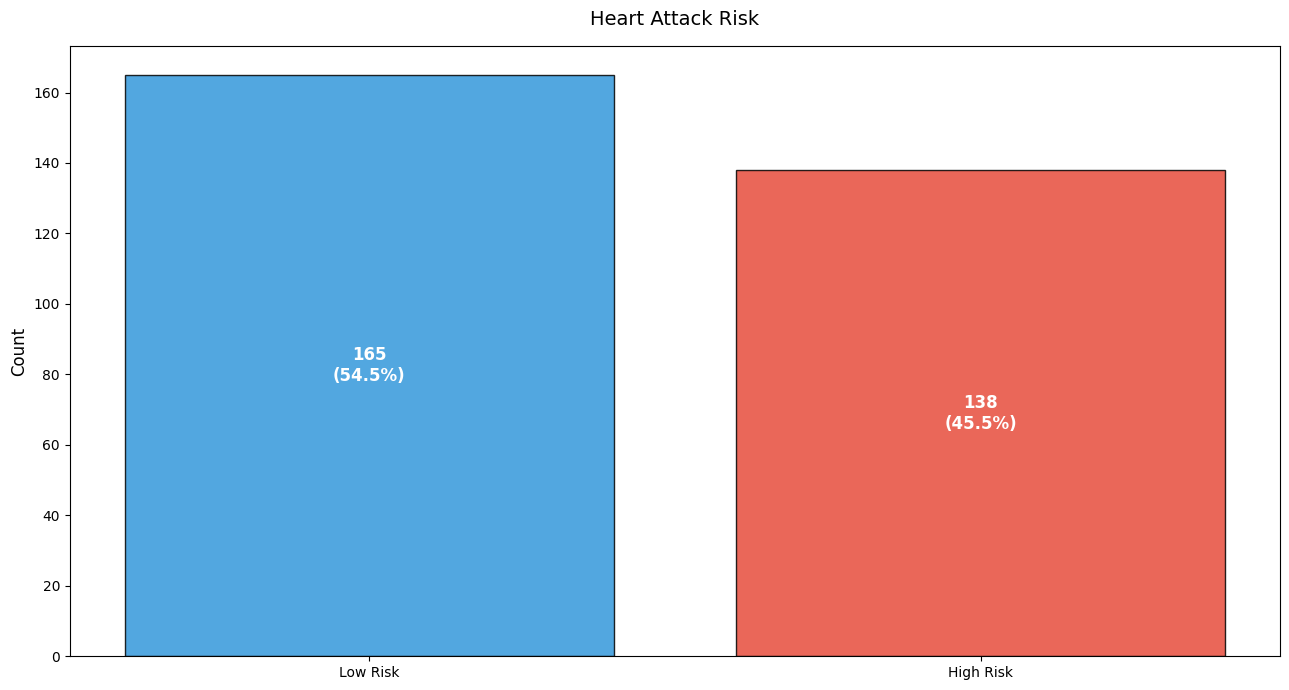

In [6]:
fig, axes = plt.subplots(figsize=(13, 7))

bars = axes.bar(
    ['Low Risk', 'High Risk'],
    counts.values,
    color=['#3498db', '#e74c3c'],
    edgecolor='black',
    alpha=0.85
)

for i in bars:
    y_val = i.get_height()
    axes.text(
        i.get_x() + i.get_width() / 2.0,
        y_val / 2,
        f"{y_val}\n({y_val / len(df) * 100:.1f}%)",
        ha='center',
        va='center',
        color='white',
        fontweight='bold',
        fontsize=12
    )

axes.set_title("Heart Attack Risk", fontsize=14, pad=15)
axes.set_ylabel("Count", fontsize=12)


plt.tight_layout()
plt.show()

# **5.1.3**
## رسم هیستوگرام و نمودار جعبهای (Boxplot)برای متغیرهای عددی مانندage، chol، trtbps و thalach

یک لیست به نام feature که نام ویژگی های عددی را در خود ذخیره میکند درست کردیم.

دستور subplot(1,4,figsize) باعث میشود ۴ نمودار در یک سطر و ۴ ستون درست شود.



```
for i, col in enumerate(Feature):
```

استفاده از enumerate(feature) در حلقه باعث میشود در هر بار که حلقه اجرا میشود دو تا خروجی بدهد که اولی ایندکس آن است که در i دخیره میشود و دومی مقدار آن است که در col ذخیره میشود.

در ادامه در این حلقه یک نمودار جعبه ای تعریف  کردیم که مقدار محور افقی ان output و محور عمودی ان همان ویژگی های عددی است که در فیچر ذخیره کردیم.

دلیل استفاده از حلقه نیز این است که برای هر یک از ویژگی های عددی یک کد مجزا ننویسیم.

در نهایت برای این ۴ ویژگی عددی نمودار های جعبه ای انها را بر اساس پرریسک و کم ریسک نمایش دادیم.



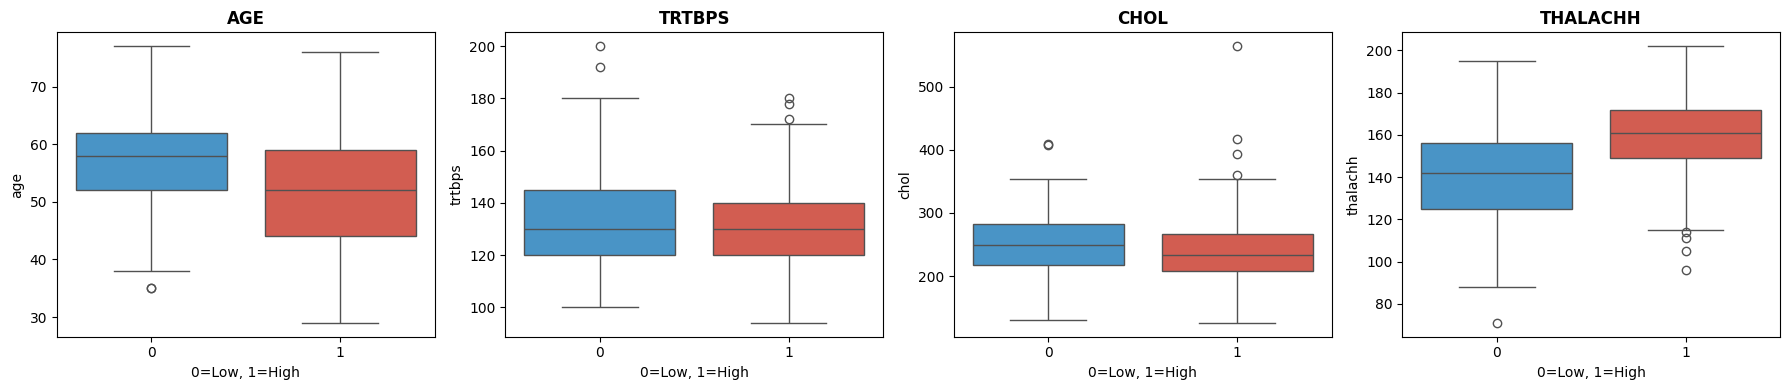

In [7]:
Feature = ['age', 'trtbps', 'chol', 'thalachh']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, col in enumerate(Feature):
    sns.boxplot(
        x = df['output'],
        y = df[col],
        hue = df['output'],
        ax = axes[i],
        palette = ['#3498db', '#e74c3c'],
        legend = False
    )
    axes[i].set_title(col.upper(), fontsize=12, fontweight='bold')
    axes[i].set_xlabel("0=Low, 1=High")

plt.tight_layout()
plt.show()

در کد زیر که مربوط به بخش قبل است نمودار توزیع مقادیر این ۴ ویژگی برای هر دو گروه پرخطر و کم خطر را نشان میدهد یا به عبارتی چگالی این ویژگی ها را در بازه های مختلف نشان میدهد.

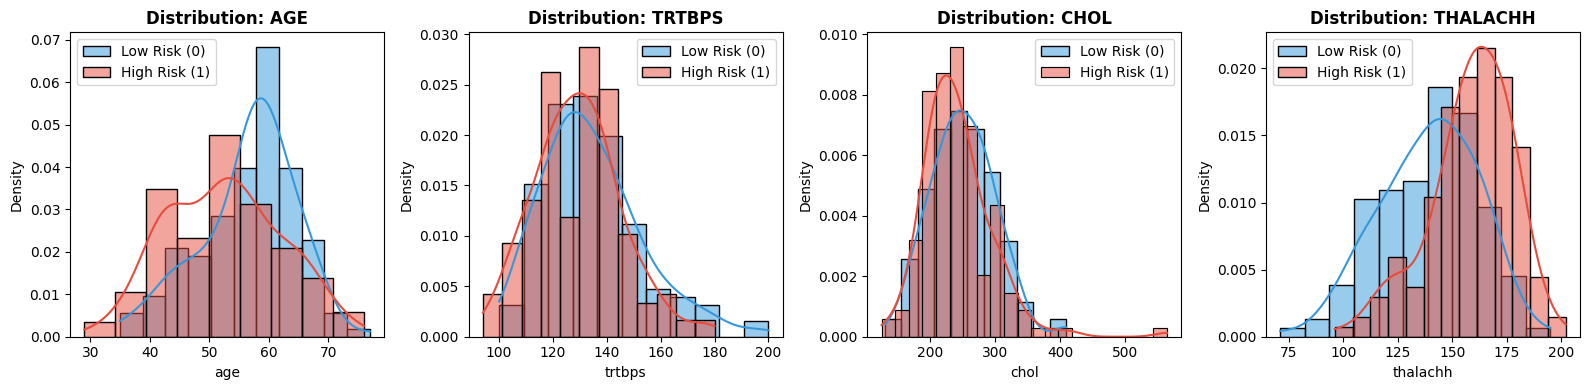

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes = axes.flatten()
for i, col in enumerate(Feature):
    sns.histplot(df[df['output']==0][col], color='#3498db', kde=True, label='Low Risk (0)', ax=axes[i], alpha=0.5, stat='density')
    sns.histplot(df[df['output']==1][col], color='#e74c3c', kde=True, label='High Risk (1)', ax=axes[i], alpha=0.5, stat='density')
    axes[i].set_title(f"Distribution: {col.upper()}", fontsize=12, fontweight='bold')
    axes[i].legend()
plt.tight_layout()
plt.show()

# 5.1.4
## بررسی همبستگی (Correlation)بین ویژگیهای عددی با استفاده از ماتریس همبستگی و نقشه ی حرارتی (Heatmap.)

ماتریس همبستگی نشون می‌ده هر جفت از ویژگی‌های عددی چقدر و چطور با هم رابطه‌ی خطی دارن. مقداری که در هر یک از مربع ها قرار دارد عددی بین -۱ تا ۱ است.

عدد -۱ یعنی همبستگی منفی قوی دارند یعنی وقتی یکی زیاد شود دیگری کم میشود. عدد ۱ یعنی همبستگی مثبت قوی و با افزایش یک ویژگی دیگری نیز افزایش میابد. همچنین هر چه به عدد صفر نزدیک تر باشد یعنی رابطه خطی معناداری بین این دو ویژگی وجود ندارد.

### توضیح کد :



```
corr_matrix = df.corr()
```

برای هر جفت ویژگی ضریب همبستگی را محاسبه میکند و ذخیره میکند.



```
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
```

این متغیر را میسازیم تا یک مثلث بالا درست کنیم تا بعدا نیمه بالایی ماتریس همبستگی را پاک کنیم تا شکل به صورت هیت مپ زیر دربیاد.

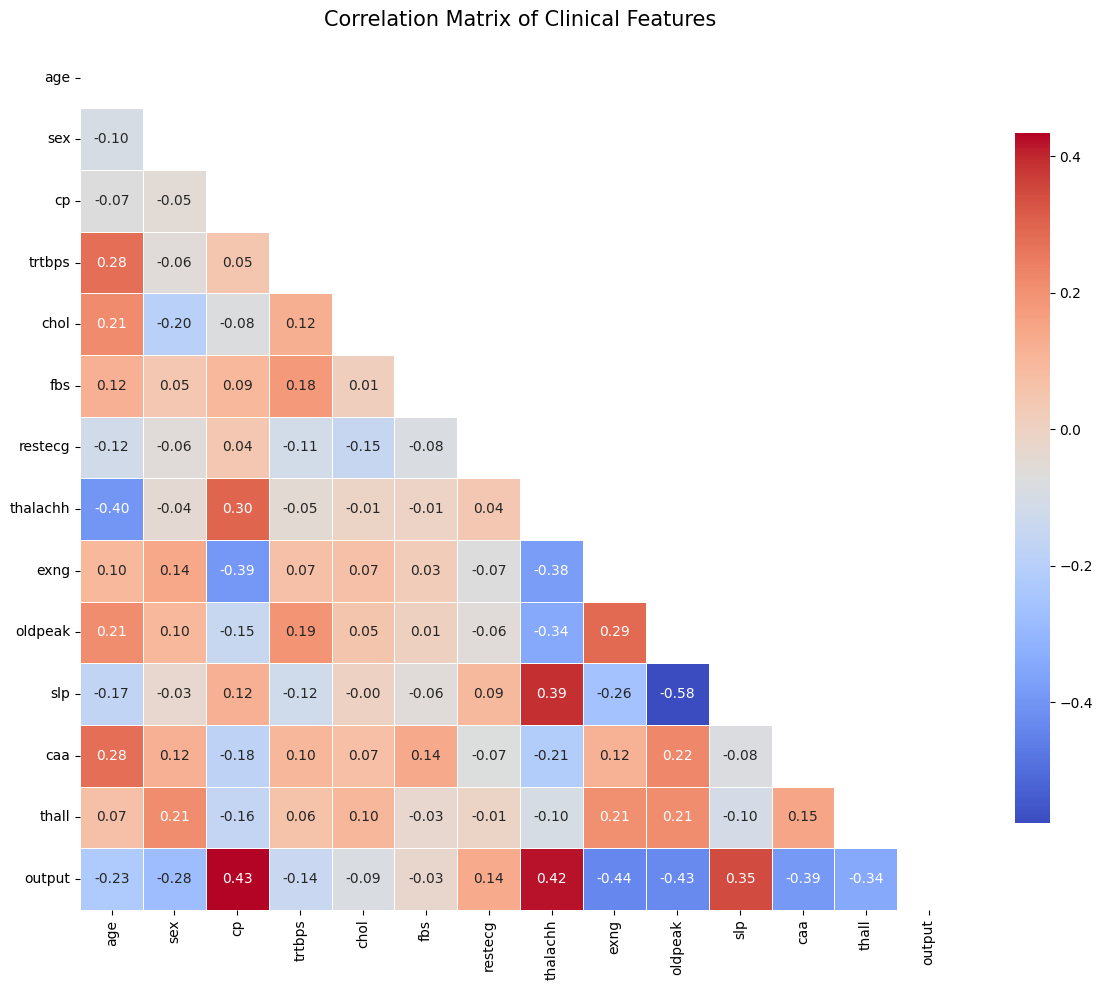

In [9]:
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'shrink': 0.8}, ax=ax, linewidths=0.5)
ax.set_title("Correlation Matrix of Clinical Features", fontsize=15, pad=15)
plt.tight_layout()
plt.show()


# 5.1.5
## مقایسه توزیع هر ویژگی بین دو کلاس target=0 , target=1 (مثلا ایا سن یا cp با ریسک حمله قلبی رابطه دارد؟)

برای هر ۱۳ ویژگی نمودار بر حسب پرخطر و کم خطر نمایش داده شده است. برای ویژگی های عددی نمودار هیستوگرام و برای ویژگی های اسمی نمودار میله ای رسم کردم تا رابطه ویژگی ها با ریسک حمله قلبی مشخص باشد.

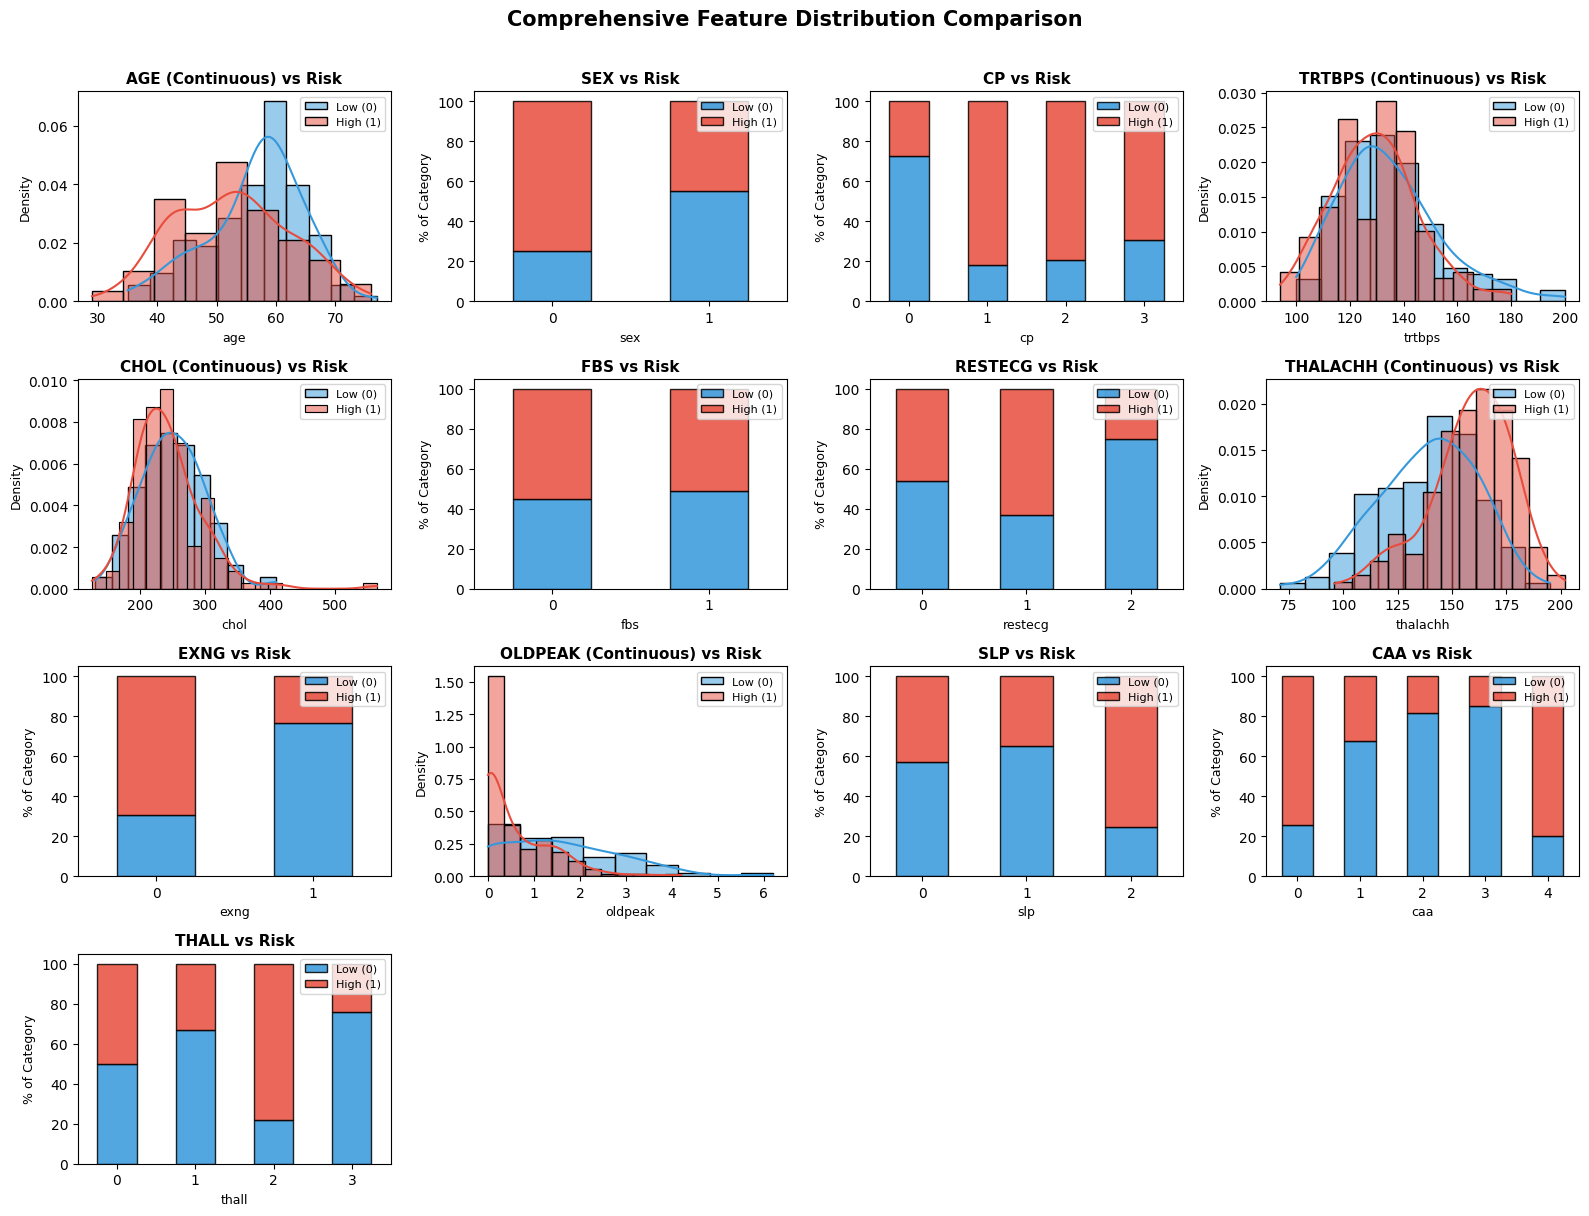

In [10]:
all_features = []
for i in df.columns :
  if i != 'output' :
    all_features.append(i)

categorical = ['sex', 'cp', 'fbs', 'restecg', 'exng', 'slp', 'caa', 'thall']

fig, axes = plt.subplots(4, 4, figsize=(16,12))
axes = axes.flatten()

for i, col in enumerate(all_features):
    ax = axes[i]
    if col in categorical:
        ct = pd.crosstab(df[col], df['output'], normalize='index') * 100
        ct.plot(kind='bar', stacked=True, color=['#3498db', '#e74c3c'], ax=ax, edgecolor='black', alpha=0.85)
        ax.set_title(f"{col.upper()} vs Risk", fontsize=11, fontweight='bold')
        ax.set_ylabel("% of Category", fontsize=9)
        ax.set_xlabel(col, fontsize=9)
        ax.legend(['Low (0)', 'High (1)'], loc='upper right', fontsize=8)
        ax.tick_params(axis='x', rotation=0)
    else:
        sns.histplot(df[df['output'] == 0][col], color='#3498db', kde=True, label='Low (0)', ax=ax, stat='density')
        sns.histplot(df[df['output'] == 1][col], color='#e74c3c', kde=True, label='High (1)', ax=ax, stat='density')
        ax.set_title(f"{col.upper()} (Continuous) vs Risk", fontsize=11, fontweight='bold')
        ax.set_ylabel("Density", fontsize=9)
        ax.set_xlabel(col, fontsize=9)
        ax.legend(loc='upper right', fontsize=8)

for i in range(len(all_features), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Comprehensive Feature Distribution Comparison", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 5.1.5
## شناسایی مقادیر گمشده (Missing Values)و بررسی الگوی احتمالی آنها.

برای شناسایی مقادیر گمشده لازم است بازه های هر ویژگی را مورد بررسی قرار دهیم و اعدادی که در این بازه قرار نداشته باشند گمشده محسوب میشوند.

**یک نکته راجع به پی دی اف وجود داشت و اون این بود که مقدار cp یک تا چهار نشان داده شده بود اما براساس دیتاست داده شده اعداد بین صفر تا سه بودند به خاطر همین من مبنای کار را بر این
گذاشتم که بازه صفر تا سه مورد قبول است.**

**توضیح کد :**
دستور loc قسمتی از df را میخواند و به کمک آن میتوانیم آن قسمت را تغییر دهیم دهیم.

مثلا در خط اول برای loc شرط گذاشته ایم که سن هایی که بالا تر از ۷۷ یا کمتر از ۲۹ بود را اناخاب کند و آن ها را برابر np.nan که همان nan است بزارد تا بتوانیم راحت تر داده های گمشده که در بازه موردنظر قرار ندارند را شناسایی کنیم.

در ادامه برای پیدا کردن تعداد داده های گمشده در هر ویژگی از دستور df.isnull().sum() استفاده کردیم که روند کارش به صورت زیر است :

دستور isnull بررسی میکند اگر داده ای nan باشد به جای آن یک و در غیر این صورت به جای ان صفر میگذارد و به کمک دستور sum همه مقدار ها را جمع میزند.


در نهایت یک جدول که تعداد داده های گمشده هر ویژگی را نشان میدهد به نمایش در میاید.

در ادامه آن افرادی که یکی از ویژگی هایشان گمشده بود ویژگی های دیگرشان نمایشداده میشود.

و در جدول آخر تعداد افراد پرخطر و کم خطر که ویژگی گمشده دارند نمایش داده شده است.

In [11]:
df.loc[(df['age'] > 77) | (df['age'] < 29), 'age'] = np.nan
df.loc[(df['sex'] != 0) & (df['sex'] != 1), 'sex'] = np.nan
df.loc[(df['cp'] > 3) | (df['cp'] < 0), 'cp'] = np.nan
df.loc[(df['trtbps'] > 200) | (df['trtbps'] < 94), 'trtbps'] = np.nan
df.loc[(df['chol'] > 564) | (df['chol'] < 126), 'chol'] = np.nan
df.loc[(df['fbs'] != 0) & (df['fbs'] != 1), 'fbs'] = np.nan
df.loc[(df['restecg'] != 0) & (df['restecg'] != 1) & (df['restecg'] != 2), 'restecg'] = np.nan
df.loc[(df['thalachh'] > 202) | (df['thalachh'] < 71), 'thalachh'] = np.nan
df.loc[(df['exng'] != 0) & (df['exng'] != 1), 'exng'] = np.nan
df.loc[(df['caa'] != 0) & (df['caa'] != 1) & (df['caa'] != 2) & (df['caa'] != 3), 'caa'] = np.nan
df.loc[(df['output'] != 0) & (df['output'] != 1), 'output'] = np.nan


missing = pd.DataFrame({
    'Number of missing data ': df.isnull().sum(),
    'Percent of missing data ': (df.isnull().sum() / len(df) * 100).round(2)
})

display(HTML(center_table(missing)))
missing_rows = df[df.isnull().any(axis=1)]
print_center_txt("Identifying missing values based on table conditions")

print('\n\n')

print_center_txt(f"Total count of missing values : {len(missing_rows)} missing")
display(HTML(center_table(missing_rows[['age', 'sex', 'cp', 'trtbps', 'chol', 'caa', 'thall', 'output']])))
print('\n\n\n')

print_center_txt("Output Distribution in Missing Values")
a = missing_rows['output'].value_counts()
a.index.name = 'Class'
a = a.reset_index()
a.index += 1
display(HTML(center_table(a)))

,Number of missing data,Percent of missing data
age,0,0.00
sex,0,0.00
cp,0,0.00
trtbps,0,0.00
chol,0,0.00
fbs,0,0.00
restecg,0,0.00
thalachh,0,0.00
exng,0,0.00
oldpeak,0,0.00


,age,sex,cp,trtbps,chol,caa,thall,output
92,52.0,1.0,2.0,138.0,223.0,NaN,2,1.0
158,58.0,1.0,1.0,125.0,220.0,NaN,3,1.0
163,38.0,1.0,2.0,138.0,175.0,NaN,2,1.0
164,38.0,1.0,2.0,138.0,175.0,NaN,2,1.0
251,43.0,1.0,0.0,132.0,247.0,NaN,3,0.0


,Class,count
1,1.0,4
2,0.0,1


# 5.2.1
## مدیریت مقادیر گمشده با روشهای مناسب (حذف رکورد، جایگذاری با میانگین/میانه/مد یا روش های پیشرفته تر مانندKNN Imputer.)

در اینجا برای جایگذاری رکورد ها از روش KNN IMPUTER استفاده کردم.

روش کار KNN :



1.   اون ردیف رو با بقیه‌ی ردیف‌ها (بر اساس ستون‌هایی که مقدار دارن) مقایسه می‌کنه.
2.   k نزدیک‌ترین همسایه (نمونه‌های مشابه‌تر) رو پیدا می‌کنه n_neighbors=5، یعنی ۵ ردیف شبیه‌ترین.
3.   مقدار گمشده رو بر اساس مقدار همون ستون در اون ۵ همسایه، با میانگین وزن دار تخمین می‌زنه.


همانطور که در جدول هم مشخص است بعد از استفاده از این روش تعداد داده های گمشده صفر میشود.



In [12]:
cols = []
for i in df.columns:
    cols.append(i)

imputer = KNNImputer(n_neighbors=5, weights='distance')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

for i in cols:
    df_imputed[i] = df_imputed[i].round().astype(int)

df = df_imputed.copy()

table = df.isnull().sum().reset_index()
table.index = table.index + 1
table.columns = ['Column', 'Count Of Missing Values']
print_center_txt("Missing Values Status After KNN Imputation")
display(HTML(center_table(table)))

,Column,Count Of Missing Values
1,age,0
2,sex,0
3,cp,0
4,trtbps,0
5,chol,0
6,fbs,0
7,restecg,0
8,thalachh,0
9,exng,0
10,oldpeak,0


# 5.2.2
## شناسایی و تصمیمگیری دربارهی دادههای پرت با استفاده از روشIQR یا Z-score



در سلول پایین نمودار جعبه ای ۵ ویژی عددی  را رسم کردم تا داده های پرت مشخص شوند.

در ادامه از روش IQR و Z-SCORE استفاده میکنیم.

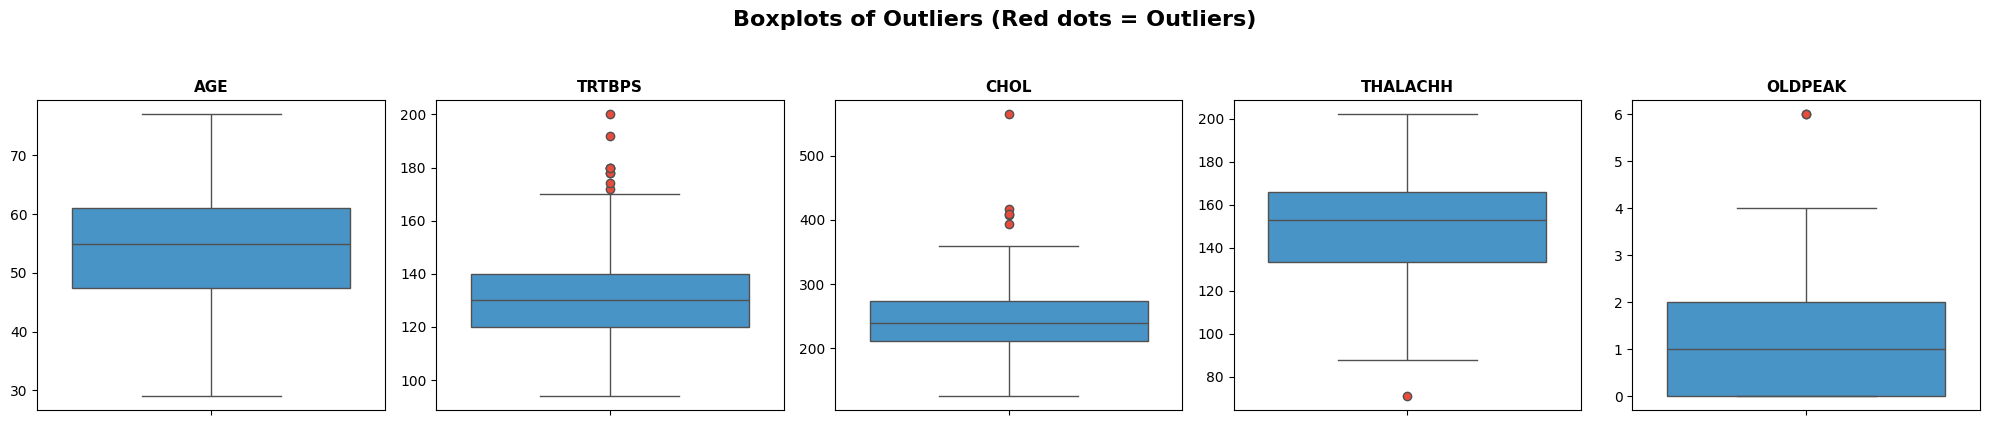

In [13]:
cols_numeric = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']

n = len(cols_numeric)
plt.figure(figsize=(4 * n, 4))

for i, col in enumerate(cols_numeric, 1):
    plt.subplot(1, n, i)
    sns.boxplot(y=df[col], color='#3498db', flierprops={'marker': 'o', 'markersize': 6, 'markerfacecolor': '#e74c3c'})
    plt.title(f"{col.upper()}", fontsize=11, fontweight='bold')
    plt.ylabel("")

plt.suptitle("Boxplots of Outliers (Red dots = Outliers)", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## Z-SCORE و IQR :

در سلول زیر ابتدا روش iqr را استفاده کردم که روش کار ان به صورت زیر است :

ابتدا چارک اول و چارک سوم را که q1 , q3 نامیدیم. و اختلاف آنها را ظiqr مینامیم. بعد برای هر ستون داده هایی را انتخاب میکنیم که زیر جعبه یا بالای جعبه باشند که زیر و بالای جعبه را به کمک چارک ها و iqr محاسبه کردیم.

در ادامه برای روش z-score برای داده های هر ستون مقدار z را محاسبه کردیم و اگر این مقدار از ۳ بیشتر باشد داده پرت محسوب میشود.

در ادامه جدولی طراحی کردیم که برای هر ویژگی عددی روش z-score و iqr را بررسی کند و تعداد داده های پرتی که هر روش نشان میدهد را نمایش دهد.

In [14]:
outlier_comparison = []

for col in cols_numeric:
    data = df[col]
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_iqr = q1 - 1.5 * iqr
    upper_iqr = q3 + 1.5 * iqr
    outliers_iqr = data[(data < lower_iqr) | (data > upper_iqr)]
    n_iqr = len(outliers_iqr)

    z_scores = np.abs(stats.zscore(data))
    outliers_z = data[z_scores > 3]
    n_z = len(outliers_z)

    outlier_comparison.append({
        'Feature': col.upper(),
        'Lower IQR': lower_iqr.round(1),
        'Upper IQR': upper_iqr.round(1),
        'Count Of Outlier (IQR)': n_iqr,
        'Percent Of Outlier (IQR)': f"{(n_iqr / len(df) * 100):.2f}%",
        'Count Of Outlier (Z-Score > 3)': n_z,
        'Percent Of Outlier(Z-Score)': f"{(n_z / len(df) * 100):.2f}%",
        'Extreme Values' : sorted(outliers_iqr.unique().tolist()) if n_iqr > 0 else []
    })

df_outliers = pd.DataFrame(outlier_comparison)
df_outliers.index += 1

print_center_txt("Outlier Detection Comparison : IQR vs Z-Score", size=20)

display(HTML(center_table(df_outliers)))

,Feature,Lower IQR,Upper IQR,Count Of Outlier (IQR),Percent Of Outlier (IQR),Count Of Outlier (Z-Score > 3),Percent Of Outlier(Z-Score),Extreme Values
1,AGE,27.2,81.2,0,0.00%,0,0.00%,[]
2,TRTBPS,90.0,170.0,9,2.97%,2,0.66%,"[172, 174, 178, 180, 192, 200]"
3,CHOL,115.8,369.8,5,1.65%,4,1.32%,"[394, 407, 409, 417, 564]"
4,THALACHH,84.8,214.8,1,0.33%,1,0.33%,[71]
5,OLDPEAK,-3.0,5.0,2,0.66%,2,0.66%,[6]


# 5.2.3
## انکد کردن متغیرهای اسمی چندمقداری مانندcpوrest_ecgبا استفاده ازOne-Hot Encoding

در سلول زیر متغیر های اسمی چند مقداری را انکود کردیم. دلیل اینکار این است که کامپیوتر مثلا برای cp فرض میکند عدد ۲ دوبرابر عدد ۱ است در حالی که عدد ۱ و ۲ صرفا نمادی برای یک اسم هستند و اندازه انها اهمیتی ندارد.

ما با انکود کردن این داده ها هر ویژگی اسمی را به چند تا ویژگی تبدیل میکنیم مثلا cp که عدد ۱ صفر تا ۳ میگیرد به ۳ دسته تبدیل شده و دلیل اینکه ۴ تا نشده این است که ۳ دسته اطلاعات کافی را به ما منتقل میکند و ما با ۴ دسته کردن آن فقط همبستگی خطی آن را شدیدا افزایش میدهیم که برای دیتا ست ما اتفاق بدی است.

In [15]:
nominal_cols = ['cp', 'restecg', 'slp', 'thall']

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)

print_center_txt(f"Data Set Dimention : {df.shape}")

display(HTML(center_table(df.head())))

,age,sex,trtbps,chol,fbs,thalachh,exng,oldpeak,caa,output,cp_1,cp_2,cp_3,restecg_1,restecg_2,slp_1,slp_2,thall_1,thall_2,thall_3
0,63,1,145,233,1,150,0,2,0,1,0,0,1,0,0,0,0,1,0,0
1,37,1,130,250,0,187,0,4,0,1,0,1,0,1,0,0,0,0,1,0
2,41,0,130,204,0,172,0,1,0,1,1,0,0,0,0,0,1,0,1,0
3,56,1,120,236,0,178,0,1,0,1,1,0,0,1,0,0,1,0,1,0
4,57,0,120,354,0,163,1,1,0,1,0,0,0,1,0,0,1,0,1,0


# 5.2.4
## استانداردسازی یا نرمالسازی ویژگیهای عددی (مانندStandardScalerیاMinMaxScaler)پیش از ورود به مدلهایی که به مقیاس حساساند.



```
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
```

در این خط به صورت رندوم ۲۰ درصد داده های ویژگی های عددی را در ایکس تست و مابقی را در ایکس ترین گذاشتیم و برای y هم که پرخطر و کم خطر بودن را نشان میدهد گذاشتیم.

در ادامه به کمک استاندارد اسکالر داده ها را استاندارد کردیم. در این روش میانگین داده ها تا حد ممکن به صفر نزدیک  میشوند و از فرمول زیر هر داده محاسبه میشود : $$z = \frac{x - \mu}{\sigma}$$



In [16]:
numeric_cols = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']
X = df[numeric_cols]
y = df['output']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print_center_txt(f"count of train data : {X_train.shape[0]} and count of test data : {X_test.shape[0]}")
print('\n\n\n')

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

df_scaler = pd.DataFrame({
    'Mean For Train Data': X_train_scaled[numeric_cols].mean().round(3),
    'Mean For Test Data': X_test_scaled[numeric_cols].mean().round(3),
    'Standard Deviation For Train Data': X_train_scaled[numeric_cols].std().round(3),
    'Standard Deviation For Test Data': X_test_scaled[numeric_cols].std().round(3)
})

df_scaler.index.name = 'Feature'
df_scaler = df_scaler.reset_index()
df_scaler.index += 1

print_center_txt("Analysis of mean and standard deviation after standardization", size = 20)
display(HTML(center_table(df_scaler)))

,Feature,Mean For Train Data,Mean For Test Data,Standard Deviation For Train Data,Standard Deviation For Test Data
1,age,0.0,0.042,1.002,0.970
2,trtbps,0.0,-0.023,1.002,0.876
3,chol,-0.0,0.144,1.002,1.371
4,thalachh,-0.0,-0.108,1.002,1.203
5,oldpeak,-0.0,-0.086,1.002,0.835


در روش minmaxscaler داده ها بین صفر و یک قرار داده میشوند.هر داده از روش زیر محسابه میشود :$$x' = \frac{x - x_{min}}{x_{max} - x_{min}}$$

همانطور که مشخص است داده ها به یک نسبت مشخص کوچک یا بزرگ میشوند.

In [17]:
min_max_scaler = MinMaxScaler()

X_train_minmax = min_max_scaler.fit_transform(X_train)
X_test_minmax = min_max_scaler.transform(X_test)

X_train_minmax = pd.DataFrame(X_train_minmax, columns=X.columns, index=X_train.index)
X_test_minmax = pd.DataFrame(X_test_minmax, columns=X.columns, index=X_test.index)

df_minmax = pd.DataFrame({
    'Min For Train Data': X_train_minmax[numeric_cols].min().round(3),
    'Min For Test Data': X_test_minmax[numeric_cols].min().round(3),
    'Max For Train Data': X_train_minmax[numeric_cols].max().round(3),
    'Max For Test Data': X_test_minmax[numeric_cols].max().round(3),
    'Mean For Train Data': X_train_minmax[numeric_cols].mean().round(3),
    'Mean For Test Data': X_test_minmax[numeric_cols].mean().round(3)
})
df_minmax.index.name = 'Feature'
df_minmax = df_minmax.reset_index()
df_minmax.index += 1

print_center_txt("Analysis of min and max after normalization", size = 20)
display(HTML(center_table(df_minmax)))

,Feature,Min For Train Data,Min For Test Data,Max For Train Data,Max For Test Data,Mean For Train Data,Mean For Test Data
1,age,0.0,0.125,1.0,0.875,0.527,0.535
2,trtbps,0.0,0.057,1.0,0.717,0.356,0.352
3,chol,0.0,0.081,1.0,1.548,0.420,0.444
4,thalachh,0.0,-0.149,1.0,0.895,0.545,0.524
5,oldpeak,0.0,0.000,1.0,0.667,0.176,0.158


# 5.2.5
## تفکیک داده به مجموعههای آموزش و آزمون (Train/Test Split)با نسبت پیشنهادی۸۰به۲۰و با حفظ نسبت کالسها (Stratified Split.)

در چند سلول قبلی داده ها را به نسبت ۲۰ به ۸۰ تفکیک کردیم.

# 5.3.1
## ساخت ویژگیهای ترکیبی جدید، مانند دستهبندی سن به گروههای سنی (جوان، میانسال، مسن).



```
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 45, 60, 100],
    labels=['young', 'middle_aged', 'senior']
)
```

در این قسمت کد یک ستون جدید ساختیم که در آن سه مقدار young , middle_aged , senior میتواند قرار بگیرد و بازه هر کدام به ترتیب ۰ تا ۴۵ و ۴۵ تا ۶۰ و ۶۰ تا ۱۰۰ تقسیم کردیم.

در ادامه در یک جدول تعداد افراد در هر کدام از این دسته ها را نمایش دادیم.

همچنین برای هر کدام از این سه تا درصد افراد پرخطر و کم خطر در یک جدول دیگر نمایش داده شده است.

در ادامه همین جدول در قالب یک نمودار میله ای نمایش داده شده است.

,Age Group,Count
1,middle_aged,160
2,senior,79
3,young,64


,Age Group,Low Risk,High Risk
1,young,25.00%,75.00%
2,middle_aged,48.75%,51.25%
3,senior,55.70%,44.30%


<Figure size 1200x700 with 0 Axes>

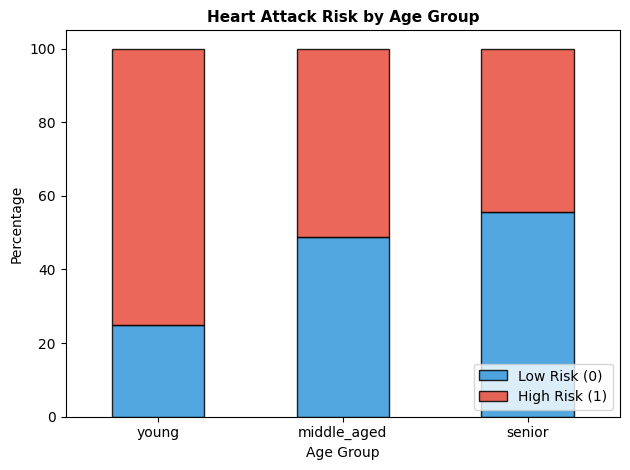

In [18]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 45, 60, 100],
    labels=['young', 'middle_aged', 'senior']
)

age_group = df['age_group'].value_counts().reset_index()
age_group.index = age_group.index + 1
age_group.columns = ['Age Group', 'Count']

print_center_txt("Count of people in each age group", size = 20)
display(HTML(center_table(age_group)))
print('\n\n\n')

age_group_risk = (pd.crosstab(df['age_group'], df['output'], normalize='index') * 100)
age_group_risk.index.name = 'Age Group'
age_group_risk = age_group_risk.reset_index()
age_group_risk.columns = ['Age Group', 'Low Risk', 'High Risk']
age_group_risk['Low Risk'] = age_group_risk['Low Risk'].apply(lambda x: f'{x:.2f}%')
age_group_risk['High Risk'] = age_group_risk['High Risk'].apply(lambda x: f'{x:.2f}%')
age_group_risk.index += 1

print_center_txt('Heart Attack Risk Percentage by Age Group', size=20)
display(HTML(center_table(age_group_risk)))

age_group_risk2 = (pd.crosstab(df['age_group'], df['output'], normalize='index') * 100)
plt.figure(figsize=(12, 7))
age_group_risk2.plot(
    kind='bar',
    stacked=True,
    color=['#3498db', '#e74c3c'],
    edgecolor='black',
    alpha=0.85,
)

plt.title('Heart Attack Risk by Age Group', fontsize=11, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Percentage')
plt.legend(['Low Risk (0)', 'High Risk (1)'], loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 5.3.2
## بررسی تعامل بین ویژگیها، مانند ترکیب فشار خون و کلسترول بهعنوان شاخص ریسک متابولیک.

شاخص ریسک متابولیسم از رابطه فشار خون ضربدر کلسترول تقسیم بر ۱۰۰۰ بدست میاید.

در این سلول نمودار میله ای متابولیسم برای افراد پرخطر و کم خطر نمایش داده شده است و طبق این نمودار میتوان متوجه شد افراد کم خطر متابولیسم بیشتری از افراد پر خطر دارند.

در ادامه به اعداد متوسط برای افراد کم خطر و پرخطر میپردازم.

/tmp/ipykernel_903/2089773340.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


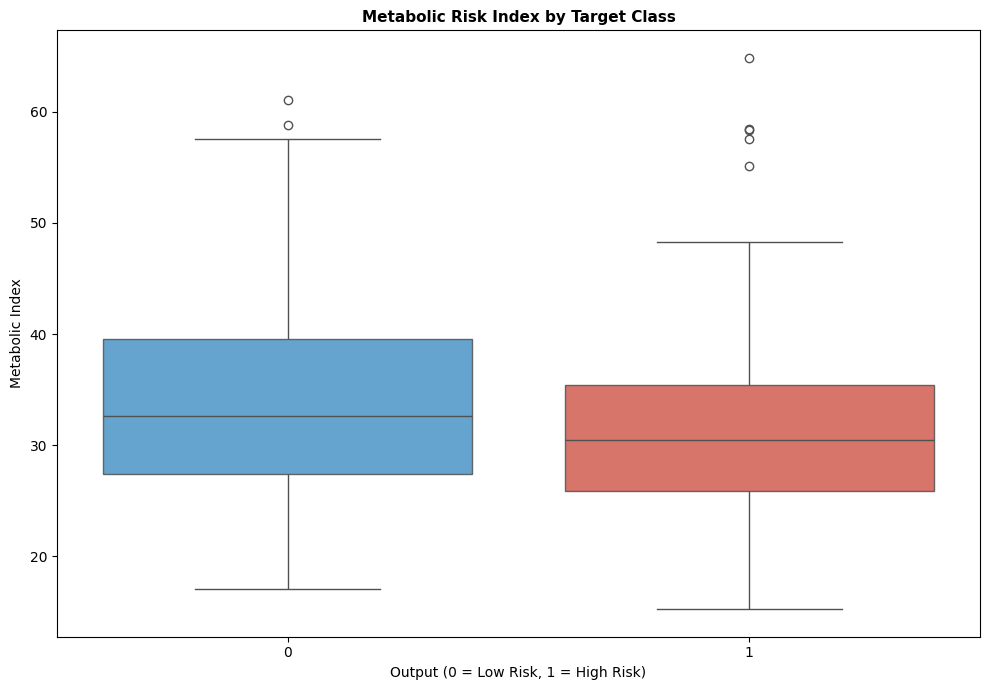

In [19]:
df['metabolic'] = (df['trtbps'] * df['chol']) / 1000.0

plt.figure(figsize=(10, 7))
plt.plot()
sns.boxplot(
    data=df,
    x='output',
    y='metabolic',
    palette=['#3498db', '#e74c3c'],
    boxprops=dict(alpha=0.85)
)
plt.title("Metabolic Risk Index by Target Class", fontsize=11, fontweight='bold')
plt.xlabel("Output (0 = Low Risk, 1 = High Risk)")
plt.ylabel("Metabolic Index")

plt.tight_layout()
plt.show()

در این سلول میانگین متابولیسم برای افراد کم خطر و پرخطر را متوجه میشویم.

در ادامه به خطر زیر میرسیم :



```
stat, probability_of_chance = stats.mannwhitneyu(group_low, group_high)
```

در این خط دستور mannwhitneyu که یک ازمون اماری است نشان میدهد آیا توزیع شاخص متابولیسم در افراد پرخطر با افراد کم‌خطر تفاوت معناداری داره، یا این اختلاف فقط شانسیه؟



In [20]:
group_low = df[df['output'] == 0]['metabolic']
group_high = df[df['output'] == 1]['metabolic']

stat, probability_of_chance = stats.mannwhitneyu(group_low, group_high)

print_center_txt(f"Average metabolic index in low-risk individuals: {group_low.mean():.2f}")
print_center_txt(f"Average metabolic index in high-risk individuals: {group_high.mean():.2f}")
print_center_txt(f"probability_of_chance: {probability_of_chance:.3f}")

if probability_of_chance < 0.05:
    print_center_txt("The difference in the metabolic index between the two groups is statistically statistically significant (p < 0.05)")
else:
    print_center_txt("No statistically significant difference was found (p ≥ 0.05)")

# 5.3.3
## بررسی اهمیت ویژگی ها (Feature Importance)با استفاده از مدل های درختی و انتخاب زیرمجموعه ی مؤثر از ویژگی ها در صورت نیاز.

به کمک دستور RandomForestClassifier یک مدل درختی رندوم میسازیم در ادامه به کمک متود feature_importances_ اهمیت هر ویژگی را در این دیتاست متوجه میشویم و نمودار ان را نمایش دادیم.

در سلول بعدی نمودار اهمیت ویژگی ها را نیز رسم کردم.

In [21]:
X = df.drop(columns=['output'])
X = pd.get_dummies(X, drop_first=True, dtype=int)
y = df['output']

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

df_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_,
    'Importance (%)': (rf_model.feature_importances_ * 100).round(2)
}).sort_values(by='Importance (%)', ascending=False).reset_index(drop=True)
df_imp['Importance (%)'] = df_imp['Importance (%)'].apply(lambda x: f"{x:.2f}%")
df_imp.index += 1

print_center_txt("Feature Importance Ranking", size=20)
display(HTML(center_table(df_imp)))

,Feature,Importance,Importance (%)
1,thalachh,0.116510,11.65%
2,caa,0.115261,11.53%
3,thall_2,0.083560,8.36%
4,age,0.081783,8.18%
5,thall_3,0.077594,7.76%
6,metabolic,0.070836,7.08%
7,trtbps,0.068822,6.88%
8,chol,0.063000,6.30%
9,oldpeak,0.056864,5.69%
10,exng,0.051443,5.14%


در اینجا نمودار رنکینگ اهمیت ویژگی ها رسم شده است .

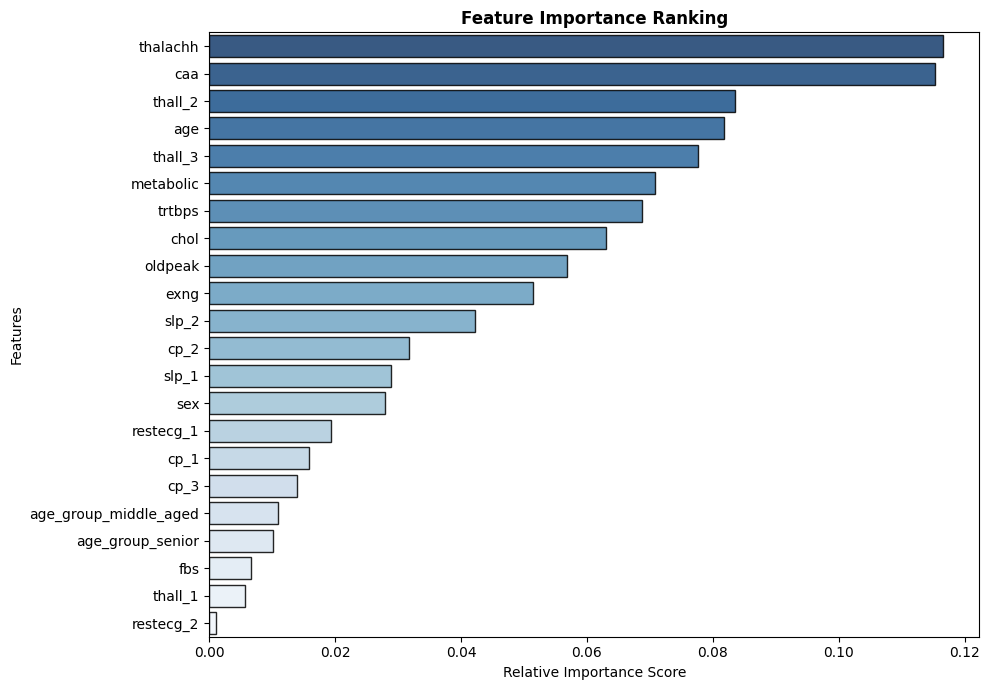

In [22]:
plt.figure(figsize=(10, 7))
df_imp_sorted = df_imp.sort_values(by='Importance', ascending=False)

sns.barplot(
    data=df_imp_sorted,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='Blues_r',
    legend=False,
    edgecolor='black',
    alpha=0.85,
)

plt.title('Feature Importance Ranking',fontsize=12,fontweight='bold')
plt.xlabel('Relative Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

در اینجا به کمک دستور SelectFromModel ویژگی های مهم تر را جدا کردیم که ۱۰ تا ویژگی بودند.

In [23]:
selector = SelectFromModel(rf_model, threshold='mean', prefit=True)
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]
discarded_features = X.columns[~selected_mask]

print_center_txt("Effective feature subset selection results", size = 20)
print_center_txt(f"Count Of Feature : {len(X.columns)}")
print_center_txt(f"Count Of Importance Feature : {len(selected_features)}")
print_center_txt(f"Count Of Unimportance Feature : {len(discarded_features)}")
print('\n\n')
print_center_txt("Top Features :", size = 20)
print_center_txt(list(selected_features))
print('\n\n')
print_center_txt("Features with lower impact", size = 20)
print_center_txt(list(discarded_features))

# 5.4.1
## رگرسیون لجستیک (Logistic Regression) بهعنوان مدل پایه (Baseline.)

 اینجا به کمک دستور لاجستیک رگرسیون مدلی درست کردیم که متود predict, predict_proba دارد که برای پیش بینی مدل روی داده های تست کار میکند.

 این ماتریس این ها را به ما نشان میدهد :

 TP = پیشبینی ۱ و داده واقعا ۱ باشد
 TN = اگر ۰ پیشبینی کند و واقعا ۰ باشد.
 FP = اگر ویشبینی کند ۱ است ولی ۰ باشد.
 FN = اگر پیشبینی کند ۰ است ولی ۱ باشد.

 در ادامه هیت مپ این مدل را برای ماتریس در خم ریختگی نمایش دادم. و چند معیار را بررسی کردم :

**Accuracy :**
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
نشان دهنده دقت کلی است و به ما میگوید مدل از کل نمونه چند درصد رو درست پیشبینی کرده است.

**Recall :**
$$\text{Recall} = \frac{TP}{TP + FN}$$
به ما نشان میدهد از بین همه‌ی افراد واقعاً پرخطر، مدل چند درصدشون رو پیدا کرده است.

**Precision :**
$$\text{Precision} = \frac{TP}{TP + FP}$$
نشان میدهد از بین افرادی که مدل گفت پرخطر، چند درصدشون واقعاً پرخطر بودن.

**F1-Score :**
$$F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$
ریکال و پرسیژن معمولا در تضاد هم هستن این معیار تعادل بین این دو رو میسنجه و برای داده های نامتوازن معمولا از اکورسی معتبرتره.


**ROC-AUC :**
نشان میدهد احتمال اینکه اگه یه فرد پرخطر و یه فرد کم‌خطر رو تصادفی انتخاب کنیم مدل به فرد پرخطر احتمال بالاتری بده.

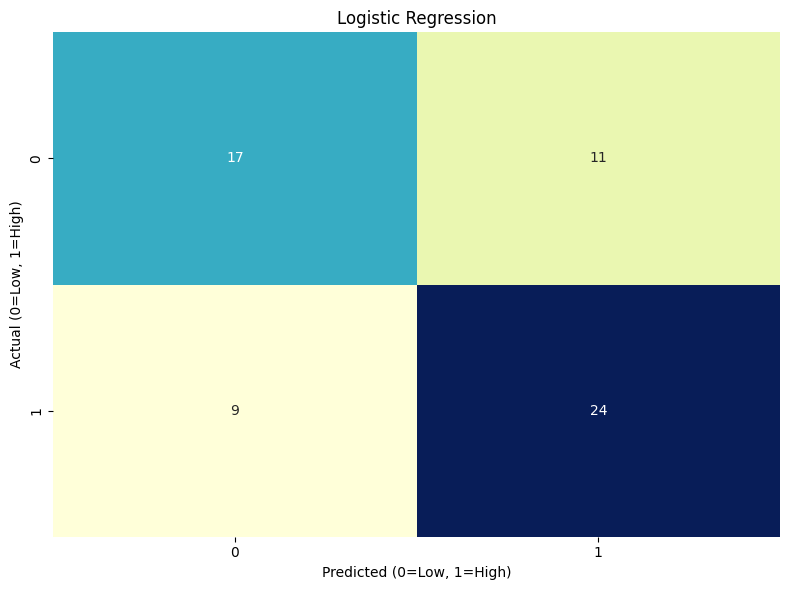

In [24]:
model_results = {}
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)

model_results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'F1-Score': f1_score(y_test, y_pred_lr),
    'ROC-AUC': roc_auc_score(y_test, y_prob_lr[:, 1]),
    'probs': y_prob_lr
}

print_center_txt("1. Logistic Regression (Baseline Model)", size=20)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title("Logistic Regression")
plt.xlabel("Predicted (0=Low, 1=High)")
plt.ylabel("Actual (0=Low, 1=High)")
plt.tight_layout()
plt.show()

for i, j in model_results['Logistic Regression'].items():
    if i != 'probs':
        print_center_txt(f"{i}: {j:.3f}")

# 5.4.2
در ادامه توضیح همه ماننند سلول ۵.۴.۱ است .

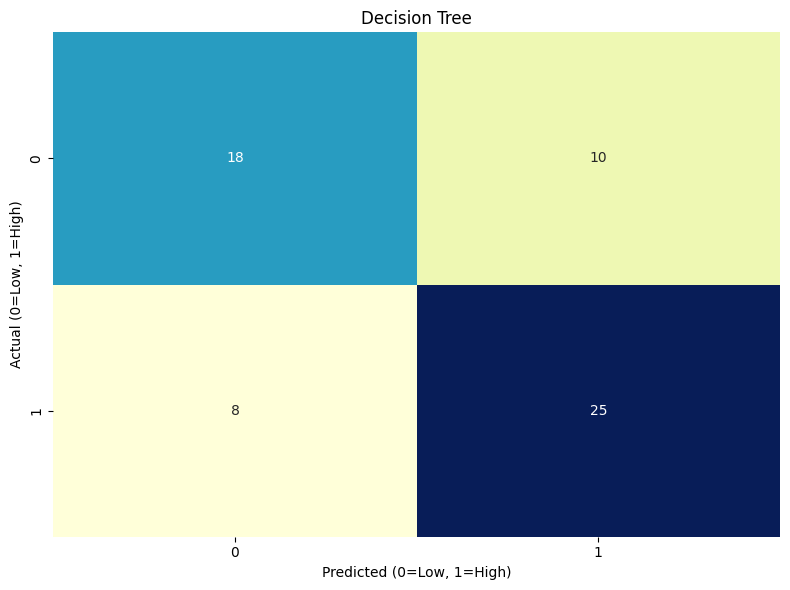

In [25]:
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)
y_prob_dt = dt_model.predict_proba(X_test_scaled)

model_results['Decision Tree'] = {
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Recall': recall_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt),
    'F1-Score': f1_score(y_test, y_pred_dt),
    'ROC-AUC': roc_auc_score(y_test, y_prob_dt[:, 1]),
    'probs': y_prob_dt
}

print_center_txt("2. Decision Tree Classifier", size=20)
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title("Decision Tree")
plt.xlabel("Predicted (0=Low, 1=High)")
plt.ylabel("Actual (0=Low, 1=High)")
plt.tight_layout()
plt.show()

for i, j in model_results['Decision Tree'].items():
    if i != 'probs':
        print_center_txt(f"{i}: {j:.4f}")

# 5.4.3

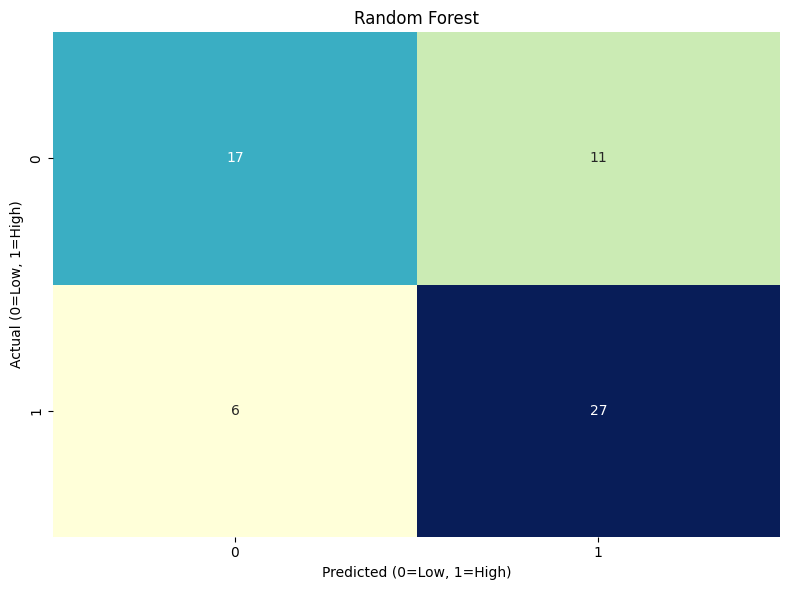

In [26]:
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_clf.fit(X_train_scaled, y_train)
y_pred_rf = rf_clf.predict(X_test_scaled)
y_prob_rf = rf_clf.predict_proba(X_test_scaled)

model_results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_prob_rf[: ,1]),
    'probs': y_prob_rf
}

print_center_txt("3. Random Forest Classifier", size=20)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title("Random Forest")
plt.xlabel("Predicted (0=Low, 1=High)")
plt.ylabel("Actual (0=Low, 1=High)")
plt.tight_layout()
plt.show()

for i, j in model_results['Random Forest'].items():
    if i != 'probs':
        print_center_txt(f"{i}: {j:.4f}")

# 5.4.4

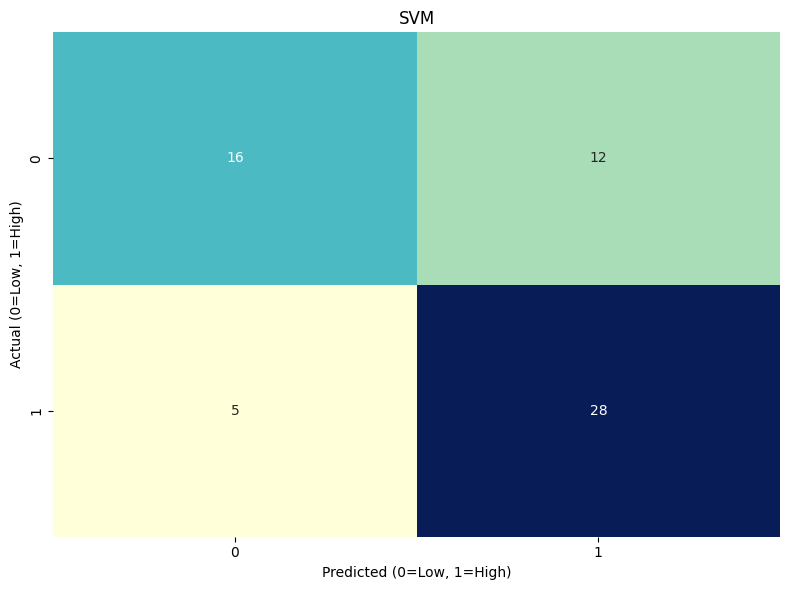

In [27]:
svm_model = SVC(kernel='rbf', probability=True, C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)

model_results['Support Vector Machine (SVM)'] = {
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'Recall': recall_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm),
    'F1-Score': f1_score(y_test, y_pred_svm),
    'ROC-AUC': roc_auc_score(y_test, y_prob_svm[:, 1]),
    'probs': y_prob_svm
}

print_center_txt("4. Support Vector Machine (SVM)", size=20)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title("SVM")
plt.xlabel("Predicted (0=Low, 1=High)")
plt.ylabel("Actual (0=Low, 1=High)")
plt.tight_layout()
plt.show()

for i, j in model_results['Support Vector Machine (SVM)'].items():
    if i != 'probs':
        print_center_txt(f"{i}: {j:.4f}")

# 5.4.5

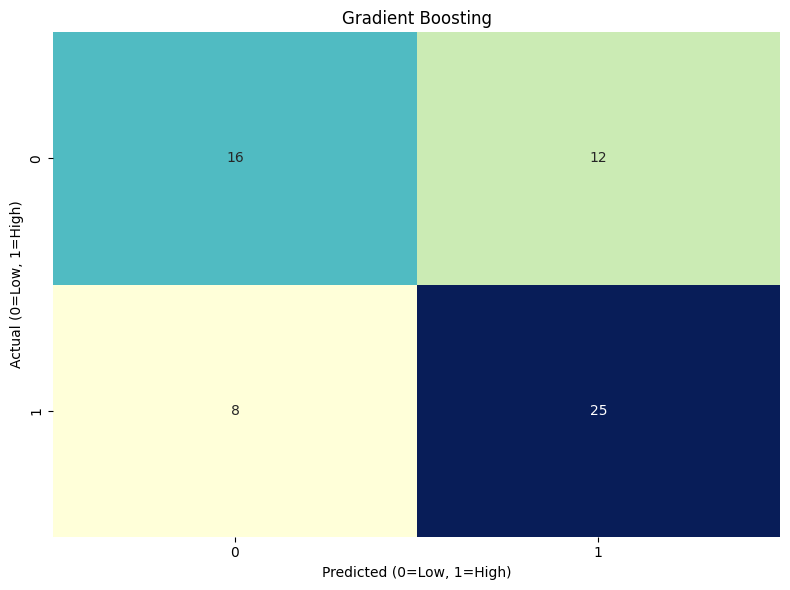

In [28]:
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.08, max_depth=3, random_state=42)
gb_model.fit(X_train_scaled, y_train)
y_pred_gb = gb_model.predict(X_test_scaled)
y_prob_gb = gb_model.predict_proba(X_test_scaled)

model_results['Gradient Boosting'] = {
    'Accuracy': accuracy_score(y_test, y_pred_gb),
    'Recall': recall_score(y_test, y_pred_gb),
    'Precision': precision_score(y_test, y_pred_gb),
    'F1-Score': f1_score(y_test, y_pred_gb),
    'ROC-AUC': roc_auc_score(y_test, y_prob_gb[:, 1]),
    'probs': y_prob_gb
}

print_center_txt("5. Gradient Boosting", size=20)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_gb), annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title("Gradient Boosting")
plt.xlabel("Predicted (0=Low, 1=High)")
plt.ylabel("Actual (0=Low, 1=High)")
plt.tight_layout()
plt.show()

for i, j in model_results['Gradient Boosting'].items():
    if i != 'probs':
        print_center_txt(f"{i}: {j:.4f}")

# 5.4.6

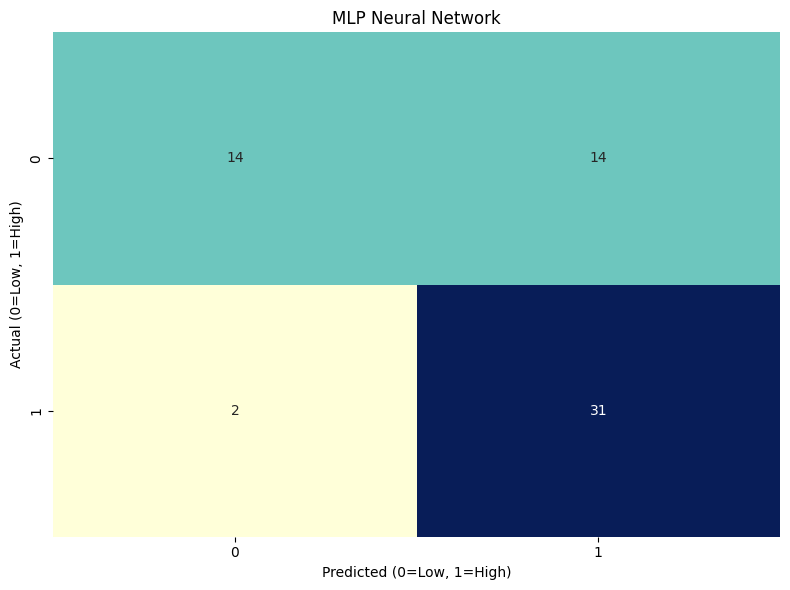

In [29]:
mlp_model = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42, early_stopping=True)
mlp_model.fit(X_train_scaled, y_train)
y_pred_mlp = mlp_model.predict(X_test_scaled)
y_prob_mlp = mlp_model.predict_proba(X_test_scaled)

model_results['MLP Neural Network'] = {
    'Accuracy': accuracy_score(y_test, y_pred_mlp),
    'Recall': recall_score(y_test, y_pred_mlp),
    'Precision': precision_score(y_test, y_pred_mlp),
    'F1-Score': f1_score(y_test, y_pred_mlp),
    'ROC-AUC': roc_auc_score(y_test, y_prob_mlp[:, 1]),
    'probs': y_prob_mlp
}

print_center_txt("6. MLP Neural Network", size=20)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_mlp), annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title("MLP Neural Network")
plt.xlabel("Predicted (0=Low, 1=High)")
plt.ylabel("Actual (0=Low, 1=High)")
plt.tight_layout()
plt.show()

for i, j in model_results['MLP Neural Network'].items():
    if i != 'probs':
        print_center_txt(f"{i}: {j:.4f}")

در اینجا یک بررسی کلی از این ۶ الگوریتم داریم که معیار ها را نسبت به هم سنجیدیم و در قالب یک جدول به نمایش دراوردیم.

In [40]:
summary_data = []
for model_name, metrics in model_results.items():
    summary_data.append({
        'Model Name': model_name,
        'Accuracy': round(metrics['Accuracy'], 3),
        'Recall (Sensitivity)': round(metrics['Recall'], 3),
        'Precision': round(metrics['Precision'], 3),
        'F1-Score': round(metrics['F1-Score'], 3),
        'ROC-AUC': round(metrics['ROC-AUC'], 3)
    })
comparison_df = pd.DataFrame(summary_data).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
comparison_df.index += 1

print_center_txt("Final Models Performance Comparison Table", size=20)
display(HTML(center_table(comparison_df)))

,Model Name,Accuracy,Recall (Sensitivity),Precision,F1-Score,ROC-AUC
1,MLP Neural Network,0.738,0.939,0.689,0.795,0.805
2,Random Forest,0.721,0.818,0.711,0.761,0.794
3,Support Vector Machine (SVM),0.721,0.848,0.700,0.767,0.787
4,Logistic Regression,0.672,0.727,0.686,0.706,0.767
5,Gradient Boosting,0.672,0.758,0.676,0.714,0.708
6,Decision Tree,0.705,0.758,0.714,0.735,0.687


در این سلول ماتریس در هم ریختگی هر ۶ تا الگوریتم را برای پیشبینی برحسب درست بودن مریضی بیمار در کنار هم اوردیم تا دید بهتری در تحلیل بهمون بده.

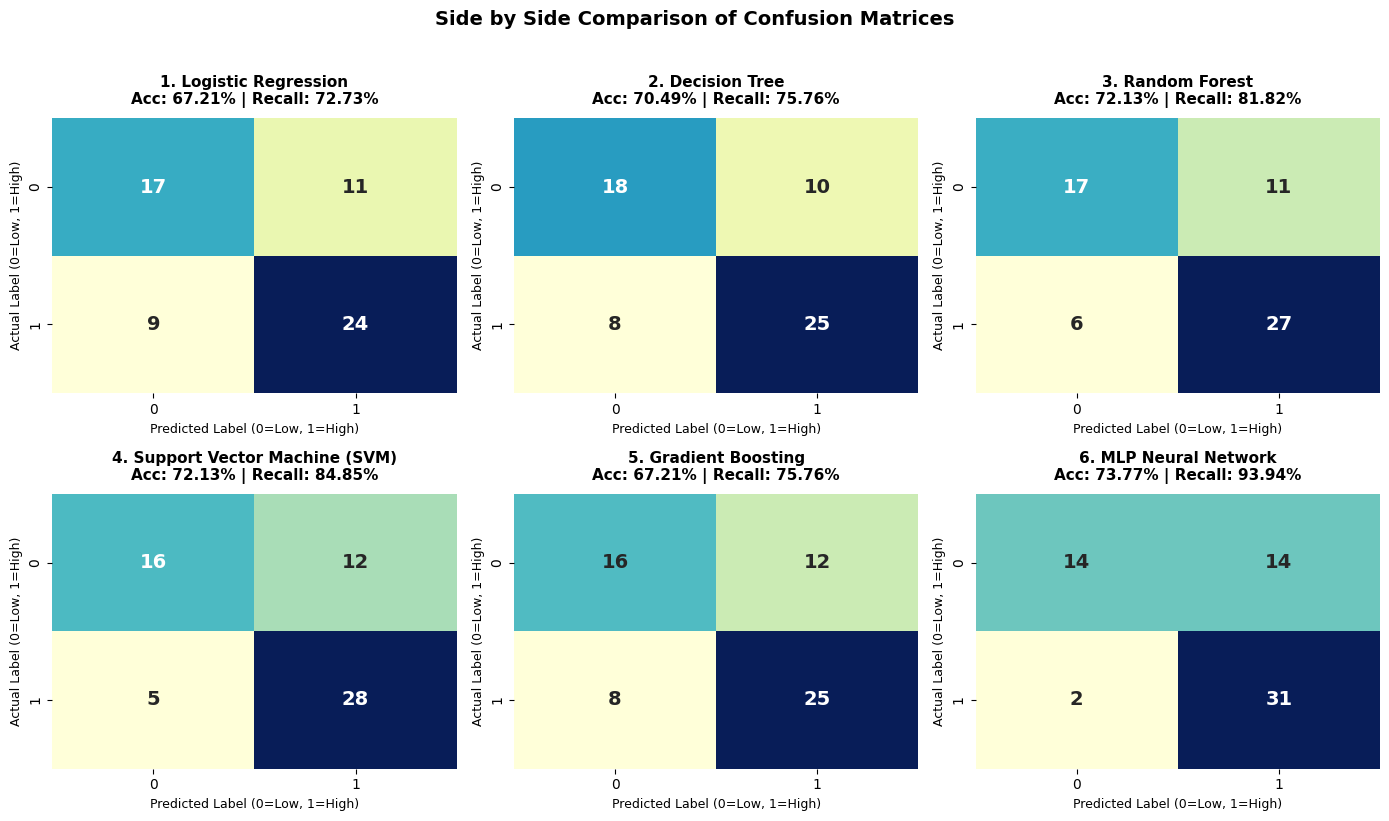

In [41]:
predictions = {
    '1. Logistic Regression': y_pred_lr,
    '2. Decision Tree': y_pred_dt,
    '3. Random Forest': y_pred_rf,
    '4. Support Vector Machine (SVM)': y_pred_svm,
    '5. Gradient Boosting': y_pred_gb,
    '6. MLP Neural Network': y_pred_mlp,
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):
  cm = confusion_matrix(y_test, y_pred)
  acc = accuracy_score(y_test, y_pred)
  rec = recall_score(y_test, y_pred)

  sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False, ax=axes[i], annot_kws={'size': 14, 'weight': 'bold'},)
  axes[i].set_title(
      f'{name}\nAcc: {acc:.2%} | Recall: {rec:.2%}',
      fontsize=11,
      fontweight='bold',
      pad=10,
  )
  axes[i].set_xlabel('Predicted Label (0=Low, 1=High)', fontsize=9)
  axes[i].set_ylabel('Actual Label (0=Low, 1=High)', fontsize=9)

plt.suptitle(
    'Side by Side Comparison of Confusion Matrices',
    fontsize=14,
    fontweight='bold',
    y=1.02,
)
plt.tight_layout()
plt.show()

# 5.5.1
در اینجا ما از gridsearchsv برای یافتن بهترین هایپرپارامتر برای هر ۶ مدل استفاده کردیم .

در اینجا برای هر مدل پارامتر ها را تعریف کردیم و آنها را در یک دیکشنری ذخیره کردیم.

در ادامه به کمک حلقه for ایتم های این دیکشنری را در name, config ذخیره کردیم و از گرید سرچ استفاده کردیم و پارامتر های هر مدل را در ان گذاشتیم و ان را اموزش دادیم.

در نهایت تست ریکال و دقت تست را برای هر ۶ مدل بررسی کردیم و در ترمینال نمایش دادم.

In [31]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models_and_grids = {
    '1. Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {
            'C': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
            'penalty': ['l2'],
            'solver': ['lbfgs', 'liblinear']
        }
    },
    '2. Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'criterion': ['gini', 'entropy']
        }
    },
    '3. Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    '4. Support Vector Machine (SVM)': {
        'model': SVC(probability=True, random_state=42),
        'params': {
            'C': [0.1, 1.0, 5.0, 10.0],
            'gamma': ['scale', 'auto', 0.05, 0.1],
            'kernel': ['rbf', 'linear']
        }
    },
    '5. Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 150],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [5, 10, None]
        }
    },
    '6. MLP Neural Network': {
        'model': MLPClassifier(random_state=42, max_iter=500, early_stopping=True),
        'params': {
            'hidden_layer_sizes': [(32,), (32, 16), (64, 32)],
            'activation': ['relu', 'tanh'],
            'alpha': [0.001, 0.01, 0.05]
        }
    }
}

tuned_results = {}
best_estimators = {}

print_center_txt("Hyperparameter Tuning Results for All 6 Models", size=20)

for name, config in models_and_grids.items():

    grid = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=cv_strategy,
        scoring='recall',
        n_jobs=-1
    )
    grid.fit(X_train_scaled, y_train)

    best_model = grid.best_estimator_
    best_estimators[name] = best_model
    y_pred = best_model.predict(X_test_scaled)
    y_prob = best_model.predict_proba(X_test_scaled)

    tuned_results[name] = {
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob[:, 1]), 4),
        'Best Params': str(grid.best_params_),
        'y_pred': y_pred,
        'y_prob': y_prob
    }

    print_center_txt(name)
    print_center_txt(f"Recall test points : {tuned_results[name]['Recall']*100:.2f}% and Test accuracy : {tuned_results[name]['Accuracy']*100:.2f}%")
    print('\n\n')

در این قسمت همان جدول قدیم را دوباره نمایش دادم با این تفاوت که ستون بهترین هایپرپارامتر به ان اضافه شد و بهترین هایپرپارامتر های هر مدل را نمایش داد.

In [42]:
cols = ['Accuracy', 'Recall', 'Precision', 'F1-Score', 'ROC-AUC', 'Best Params']

df_comparison = (
    pd.DataFrame.from_dict(tuned_results, orient='index')[cols].rename(columns={'Best Params': 'Best Hyperparameters'}).reset_index().rename(columns={'index': 'Model'}).sort_values(by='Model').reset_index(drop=True))

df_comparison.index += 1

print_center_txt("Final Performance Table After Hyperparameter Tuning", size=20)
display(HTML(center_table(df_comparison)))

,Model,Accuracy,Recall,Precision,F1-Score,ROC-AUC,Best Hyperparameters
1,1. Logistic Regression,0.6721,0.7879,0.6667,0.7222,0.7814,"{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}"
2,2. Decision Tree,0.6721,0.6970,0.6970,0.6970,0.6943,"{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}"
3,3. Random Forest,0.7213,0.7879,0.7222,0.7536,0.7890,"{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}"
4,4. Support Vector Machine (SVM),0.6885,0.7576,0.6944,0.7246,0.7716,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}"
5,5. Gradient Boosting,0.6885,0.7879,0.6842,0.7324,0.7186,"{'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 50}"
6,6. MLP Neural Network,0.7377,0.9394,0.6889,0.7949,0.8052,"{'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (32, 16)}"


در اینجا ماتریس در هم ریختگی را دوباره رسم کردم با این تفاوت که این ماتریس برای مدل های بعد از اعمال gridsearchcv روی انها است.


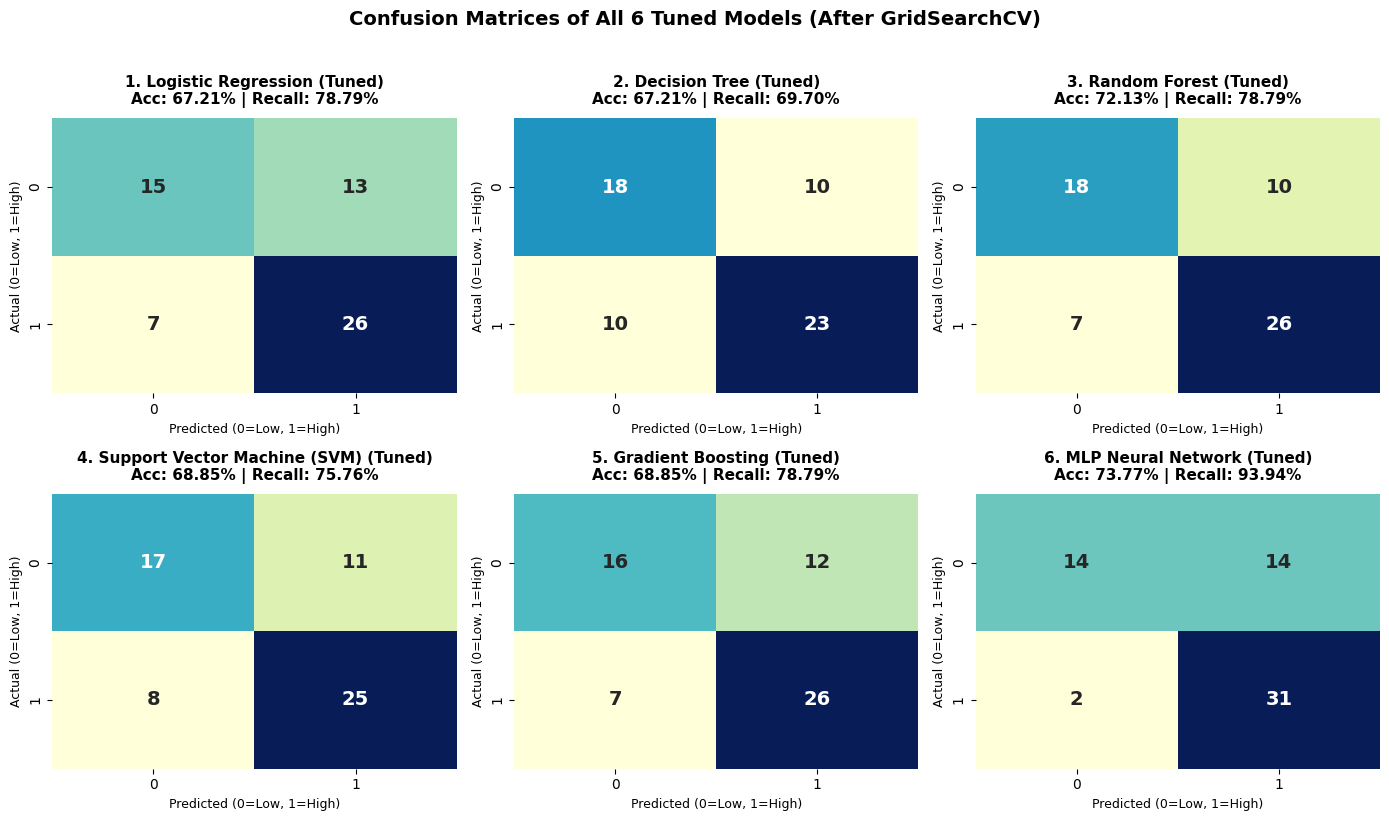

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (name, metrics) in enumerate(tuned_results.items()):
    cm = confusion_matrix(y_test, metrics['y_pred'])
    acc = metrics['Accuracy']
    rec = metrics['Recall']

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='YlGnBu',
        cbar=False,
        ax=axes[i],
        annot_kws={'size': 14, 'weight': 'bold'}
    )
    axes[i].set_title(f"{name} (Tuned)\nAcc: {acc:.2%} | Recall: {rec:.2%}", fontsize=11, fontweight='bold', pad=10)
    axes[i].set_xlabel("Predicted (0=Low, 1=High)", fontsize=9)
    axes[i].set_ylabel("Actual (0=Low, 1=High)", fontsize=9)

plt.suptitle("Confusion Matrices of All 6 Tuned Models (After GridSearchCV)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 5.5.2
این سلول مدل ها رو ارزیابی میکنه تا بیبینه که عملکردشون پایدار هست یا فقط روی داده های تست عملکرد خوبی داشتند.

همچنین n_split = k است که دو مقدار ۵ و۱۰ به ان دادیم که k تعداد بخش‌ هاییه که داده آموزش به اون‌ها تقسیم می‌شه.

در نهایت جدولی کشیدیم که عملکرد k = 5 , 10 رو مورد بررسی قرار دهد.

In [34]:
scoring_metrics = ['accuracy', 'recall', 'f1', 'roc_auc']
tble = []

for k in [5, 10]:
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    for name, model in best_estimators.items():
        scores = cross_validate(model, X_train_scaled, y_train, cv=skf, scoring=scoring_metrics, n_jobs=-1)

        tble.append({
            'Model': name,
            'K-Folds': f"K = {k}",
            'Mean Accuracy': f"{scores['test_accuracy'].mean():.2%} (± {scores['test_accuracy'].std():.2%})",
            'Mean Recall': f"{scores['test_recall'].mean():.2%} (± {scores['test_recall'].std():.2%})",
            'Mean F1-Score': f"{scores['test_f1'].mean():.2%}",
            'Mean ROC-AUC': f"{scores['test_roc_auc'].mean():.3f}",
            'Accuracy_raw': scores['test_accuracy'].mean(),
            'Std_raw': scores['test_accuracy'].std(),
            'K_val': k
        })

df_cv_results = pd.DataFrame(tble)
df_cv_results.index += 1

print_center_txt("Cross Validation Stability Report", size=20)
display(HTML(center_table(df_cv_results[['Model', 'K-Folds', 'Mean Accuracy', 'Mean Recall', 'Mean F1-Score', 'Mean ROC-AUC']])))

,Model,K-Folds,Mean Accuracy,Mean Recall,Mean F1-Score,Mean ROC-AUC
1,1. Logistic Regression,K = 5,70.60% (± 10.36%),84.79% (± 9.47%),75.88%,0.795
2,2. Decision Tree,K = 5,71.50% (± 3.91%),75.10% (± 8.87%),73.97%,0.721
3,3. Random Forest,K = 5,72.29% (± 9.25%),79.52% (± 10.25%),75.65%,0.738
4,4. Support Vector Machine (SVM),K = 5,72.30% (± 8.85%),82.54% (± 10.24%),76.32%,0.786
5,5. Gradient Boosting,K = 5,66.95% (± 5.06%),75.10% (± 11.26%),70.90%,0.669
6,6. MLP Neural Network,K = 5,65.27% (± 3.18%),81.74% (± 9.65%),71.75%,0.719
7,1. Logistic Regression,K = 10,70.62% (± 11.34%),84.84% (± 11.42%),75.87%,0.783
8,2. Decision Tree,K = 10,70.23% (± 7.66%),73.46% (± 12.40%),72.55%,0.706
9,3. Random Forest,K = 10,73.48% (± 10.19%),80.16% (± 13.06%),76.41%,0.754
10,4. Support Vector Machine (SVM),K = 10,71.83% (± 11.25%),82.42% (± 9.26%),76.28%,0.770


# 5.6.1

در اینجا همان ماتریس درهم ریختگی ها را برای قبل و بعد از اعمال gridsearchcv کشیدیم.

تفسیر ان هم که قبلا گفتیم به این صورت است :

محور عمودی برچسب واقعی یعنی چیزی که اتفاق افتاده و محور افقی پیشبینی مدل ما برای پرخطر و کم خطر بودن است و اعدادی که در هر مستطیل امده است تعداد افرادی است که مثلا هم مدل پرخطر پیشبینی کرده و هم واقعا پر خطر است و یا مدل پرخطر پیشبینی کرده اما کم خطر است یا مدل کم خطر پیشبینی کرده اما پرخطر است یا مدل کم خطر پیشبیینی کرده و واقعا کم خطر است.

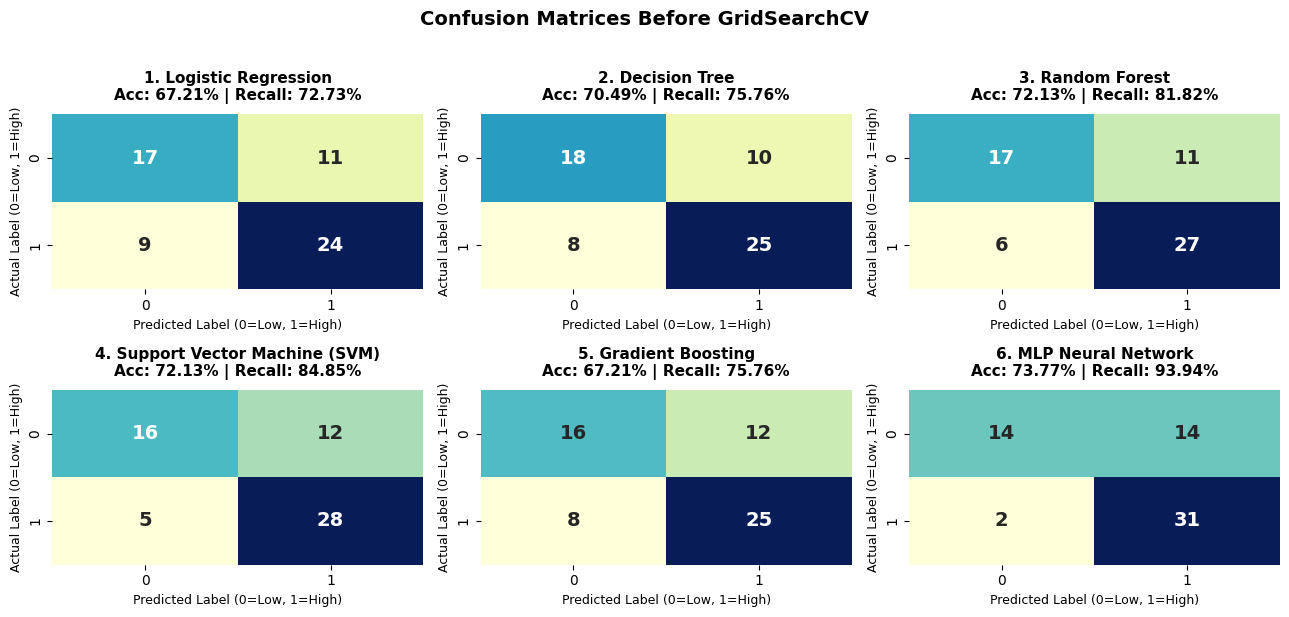

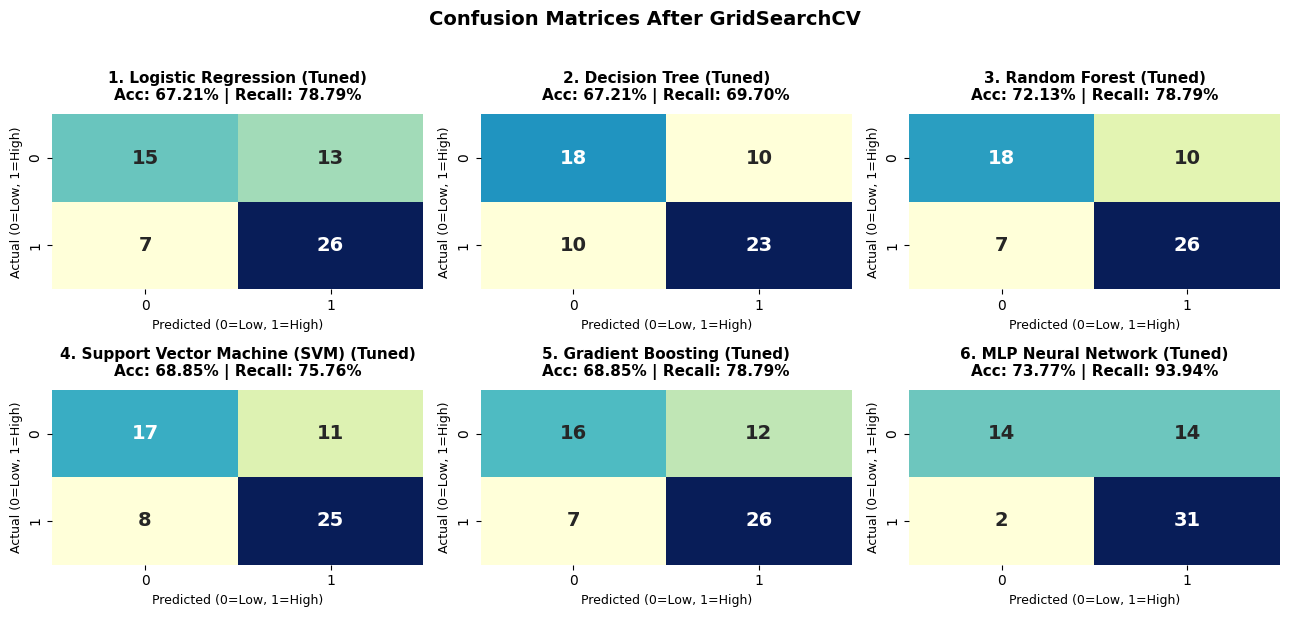

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):
  cm = confusion_matrix(y_test, y_pred)
  acc = accuracy_score(y_test, y_pred)
  rec = recall_score(y_test, y_pred)

  sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False, ax=axes[i], annot_kws={'size': 14, 'weight': 'bold'},)
  axes[i].set_title(f'{name}\nAcc: {acc:.2%} | Recall: {rec:.2%}', fontsize=11, fontweight='bold', pad=10)
  axes[i].set_xlabel('Predicted Label (0=Low, 1=High)', fontsize=9)
  axes[i].set_ylabel('Actual Label (0=Low, 1=High)', fontsize=9)

plt.suptitle('Confusion Matrices Before GridSearchCV',fontsize=14,fontweight='bold',y=1.02)
plt.tight_layout()
plt.show()


print('\n\n\n\n\n\n')


fig, axes = plt.subplots(2, 3, figsize=(13, 6))
axes = axes.flatten()

for i, (name, metrics) in enumerate(tuned_results.items()):
    cm = confusion_matrix(y_test, metrics['y_pred'])
    acc = metrics['Accuracy']
    rec = metrics['Recall']

    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False, ax=axes[i],annot_kws={'size': 14, 'weight': 'bold'})
    axes[i].set_title(f"{name} (Tuned)\nAcc: {acc:.2%} | Recall: {rec:.2%}", fontsize=11, fontweight='bold', pad=10)
    axes[i].set_xlabel("Predicted (0=Low, 1=High)", fontsize=9)
    axes[i].set_ylabel("Actual (0=Low, 1=High)", fontsize=9)

plt.suptitle("Confusion Matrices After GridSearchCV", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 5.6.2 and 5.6.3
در قسمت ۵.۴ به صورت کامل مورد بررسی قرار گرفتند.

# 5.6.4

این جدول قبلا هم رسم شده و نیازی به توضیح ندارد.

In [36]:
df_summary = (
    pd.DataFrame(model_results).T.drop(columns=['probs'])
)
df_summary = df_summary.round(2)

df_summary.index.name = 'Model'
df_summary = df_summary.reset_index()
df_summary.index += 1

print_center_txt('Model Performance Comparison', size=20)
display(HTML(center_table(df_summary)))

print('\n\n\n\n')

df_tuned_summary = pd.DataFrame(tuned_results).T.drop(columns=['y_pred', 'y_prob'])
df_tuned_summary = df_tuned_summary.drop(columns=['Best Params'])
df_tuned_summary.index.name = 'Model'
df_tuned_summary = df_tuned_summary.reset_index()
df_tuned_summary.index += 1

print_center_txt(' Models Performance Comparison After GridSearchCV', size=20)
display(HTML(center_table(df_tuned_summary)))

,Model,Accuracy,Recall,Precision,F1-Score,ROC-AUC
1,Logistic Regression,0.672131,0.727273,0.685714,0.705882,0.767316
2,Decision Tree,0.704918,0.757576,0.714286,0.735294,0.687229
3,Random Forest,0.721311,0.818182,0.710526,0.760563,0.794372
4,Support Vector Machine (SVM),0.721311,0.848485,0.7,0.767123,0.786797
5,Gradient Boosting,0.672131,0.757576,0.675676,0.714286,0.707792
6,MLP Neural Network,0.737705,0.939394,0.688889,0.794872,0.805195


,Model,Accuracy,Recall,Precision,F1-Score,ROC-AUC
1,1. Logistic Regression,0.6721,0.7879,0.6667,0.7222,0.7814
2,2. Decision Tree,0.6721,0.697,0.697,0.697,0.6943
3,3. Random Forest,0.7213,0.7879,0.7222,0.7536,0.789
4,4. Support Vector Machine (SVM),0.6885,0.7576,0.6944,0.7246,0.7716
5,5. Gradient Boosting,0.6885,0.7879,0.6842,0.7324,0.7186
6,6. MLP Neural Network,0.7377,0.9394,0.6889,0.7949,0.8052


# 5.6.5
در اینجا نمودار میله ای برای هر ۶ مدل را رسم کردیم که برای هر مدلrecall , roc_auc , f1-score , accuracy بر حسب درصدشان رسم شده است.

همانطور که در نمودار مشخص است در ۵ تا از  ۶ مدل میله قرمز بالاترین میله است که نشان میدهد این معیار از اهمیت زیادی برخوردار است


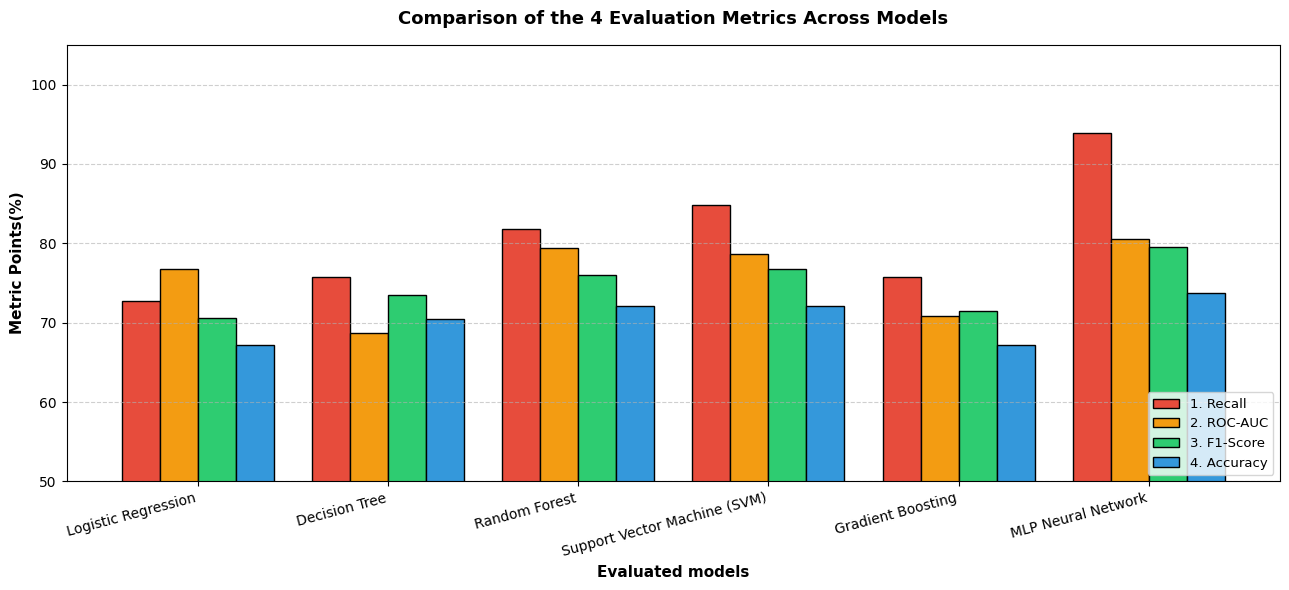

In [37]:
models = list(model_results.keys())
recalls = [model_results[m]['Recall'] * 100 for m in models]
aucs = [model_results[m]['ROC-AUC'] * 100 for m in models]
f1s = [model_results[m]['F1-Score'] * 100 for m in models]
accuracies = [model_results[m]['Accuracy'] * 100 for m in models]

plt.figure(figsize=(13, 6))

x = np.arange(len(models))
width = 0.2

plt.bar(
    x - 1.5 * width,
    recalls,
    width,
    label='1. Recall',
    color='#e74c3c',
    edgecolor='black',
)
plt.bar(
    x - 0.5 * width,
    aucs,
    width,
    label='2. ROC-AUC',
    color='#f39c12',
    edgecolor='black',
)
plt.bar(
    x + 0.5 * width,
    f1s,
    width,
    label='3. F1-Score',
    color='#2ecc71',
    edgecolor='black',
)
plt.bar(
    x + 1.5 * width,
    accuracies,
    width,
    label='4. Accuracy',
    color='#3498db',
    edgecolor='black',
)

plt.xlabel('Evaluated models', fontsize=11, fontweight='bold')
plt.ylabel('Metric Points(%)', fontsize=11, fontweight='bold')
plt.title(
    'Comparison of the 4 Evaluation Metrics Across Models',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.xticks(x, models, rotation=15, ha='right')
plt.ylim(50, 105)
plt.legend(loc='lower right', fontsize=9.5)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [38]:
metrics_importance_data = [
    {
        'Metric Name': 'Recall (Sensitivity)',
        'Math Formula': 'TP / (TP + FN)',
        'Priority Rationale': (
            'Undetected cardiac ischemia leads to sudden cardiac death; Recall'
            ' must be maximized.'
        ),
    },
    {
        'Metric Name': 'ROC-AUC',
        'Math Formula': 'Area Under the ROC Curve',
        'Priority Rationale': (
            'Threshold-independent; measures probabilistic ranking quality of'
            ' the model.'
        ),
    },
    {
        'Metric Name': 'F1-Score',
        'Math Formula': '2 * (Prec * Rec) / (Prec + Rec)',
        'Priority Rationale': (
            'Prevents trivial models from flagging all patients as high-risk to'
            ' achieve high Recall.'
        ),
    },
    {
        'Metric Name': 'Accuracy',
        'Math Formula': '(TP + TN) / Total',
        'Priority Rationale': (
            'Misleading in healthcare; penalizes harmless False Positives and'
            ' fatal False Negatives equally.'
        ),
    },
]

df_metrics_rank = pd.DataFrame(metrics_importance_data)
df_metrics_rank.index += 1
df_metrics_rank.index.name = 'Rank'
print_center_txt(
    'Medical Evaluation Metric Priority Ranking (Which is More Important?)',
    size=20,
)
display(HTML(center_table(df_metrics_rank)))

,Metric Name,Math Formula,Priority Rationale
Rank,,,
1,Recall (Sensitivity),TP / (TP + FN),Undetected cardiac ischemia leads to sudden cardiac death; Recall must be maximized.
2,ROC-AUC,Area Under the ROC Curve,Threshold-independent; measures probabilistic ranking quality of the model.
3,F1-Score,2 * (Prec * Rec) / (Prec + Rec),Prevents trivial models from flagging all patients as high-risk to achieve high Recall.
4,Accuracy,(TP + TN) / Total,Misleading in healthcare; penalizes harmless False Positives and fatal False Negatives equally.
